<h1 style="text-align:center;"> Model Explainability & Fairness | Optimization & Evaluation</h1>


In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 📘 What This Notebook Covers

In this notebook, we aim to **train**, **evaluate** and **explain** a machine learning model for movie rating classification.  
Our goal is to build a model that is not only **accurate**, but also **interpretable** and **fair**.

- We start by training an **interpretable model** (Decision Tree).
- Then, we apply **SHAP** to understand which features influence the model’s predictions the most.
- We analyze the model’s decisions to check for any **bias or fairness concerns** in the data or predictions.
- Next, we improve the model using **hyperparameter tuning** (GridSearch and RandomizedSearch).
- Finally, we **evaluate and compare** different models using proper metrics like **accuracy**, **precision**, **recall** and **ROC/AUC**.

As a bonus, we also implement a **full classification pipeline** that tests several models and shows which one works best.
___

### Why Decision Tree Classifier is Appropriate for Interpretability

- **Transparent Structure**: Decision Trees split data based on clear, human-readable rules, making the model logic easy to follow.
- **Feature Importance**: They naturally provide feature importance scores based on how much each feature contributes to reducing impurity.
- **Visual Interpretability**: The entire tree can be visualized, showing exactly how decisions are made at each node.
- **No Complex Assumptions**: Unlike black-box models (e.g. neural networks), decision trees don't rely on complex transformations, making their decisions straightforward.
- **Local Explanations**: Each individual prediction can be traced through the specific path it took in the tree, allowing for easy case-by-case explanations.


In [70]:
df = pd.read_csv('tmdb_movies_cleaned.csv')

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9953 entries, 0 to 9952
Data columns (total 46 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          9953 non-null   int64  
 1   title                       9953 non-null   object 
 2   runtime                     9953 non-null   int64  
 3   release_date                9953 non-null   object 
 4   budget                      9953 non-null   int64  
 5   revenue                     9953 non-null   int64  
 6   popularity                  9953 non-null   float64
 7   vote_average                9953 non-null   float64
 8   vote_count                  9953 non-null   int64  
 9   belongs_to_collection       9953 non-null   int64  
 10  has_tagline                 9953 non-null   int64  
 11  has_homepage                9953 non-null   int64  
 12  num_same_title              9953 non-null   int64  
 13  changed_title               9953 

In [72]:
# Create a copy of the original data to work on
data_copy = df.copy()

____
### 🎯 Classification Goal: Predicting Movie Rating Levels

In this part of the project, our goal is to predict how good a movie is, based on its features.  
We use the `weighted_rating` column as the target, since it reflects both the average rating and the number of voters — making it more reliable than just using the raw average.

This rating is not arbitrary — it is calculated using the official IMDb formula:  
> **Weighted Rating = (v / (v + m)) × R + (m / (v + m)) × C**  
where *v* is the number of votes, *R* is the average rating, *C* is the mean rating across all movies, and *m* is a vote threshold.

To turn this into a classification problem, we split the ratings into 3 levels:  
**Low**, **Good**, and **Excellent**.

This helps us train a model that learns to classify movies based on their features.  
We start with a **Decision Tree Classifier** because it’s interpretable, works well with different types of data, and shows which features are most important for the prediction.


In [73]:
print("Summary statistics for 'weighted_rating':")
display(data_copy['weighted_rating'].describe())

Summary statistics for 'weighted_rating':


count    9953.000000
mean        6.442062
std         0.618833
min         3.057064
25%         6.092196
50%         6.356828
75%         6.795872
max         8.699763
Name: weighted_rating, dtype: float64

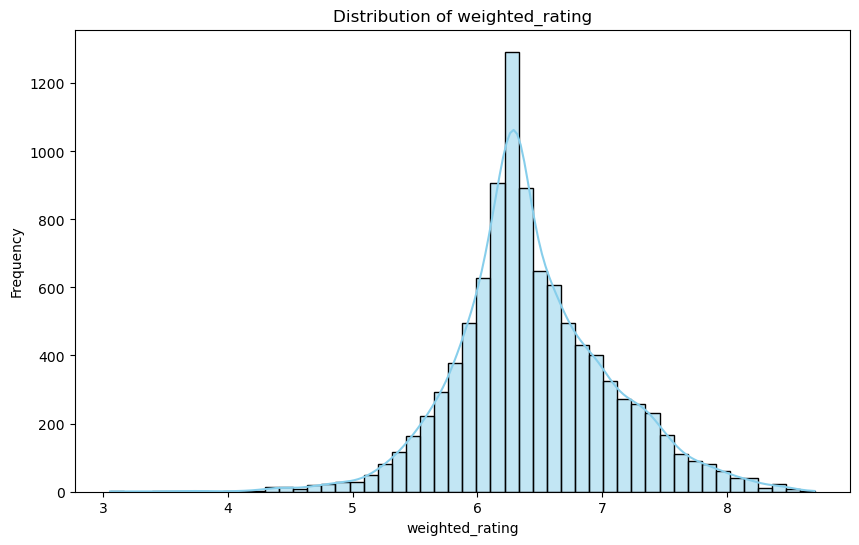

In [74]:
# Before splitting the `weighted_rating` into classes, we explored its distribution to understand its shape, presence of outliers, and whether it’s appropriate for classification

plt.figure(figsize=(10, 6))
sns.histplot(df['weighted_rating'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of weighted_rating')
plt.xlabel('weighted_rating')
plt.ylabel('Frequency')
plt.show()

In [75]:
from scipy.stats import skew, kurtosis

skewness = skew(data_copy['weighted_rating'])
kurt = kurtosis(data_copy['weighted_rating'])

print(f"Skewness: {skewness:.3f}")
print(f"Kurtosis: {kurt:.3f}")

Skewness: 0.218
Kurtosis: 0.980


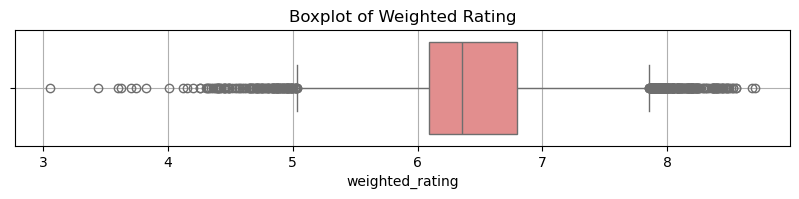

In [76]:
plt.figure(figsize=(10, 1.5))
sns.boxplot(x=data_copy['weighted_rating'], color='lightcoral')
plt.title('Boxplot of Weighted Rating')
plt.grid(True)
plt.show()

### 🎯 Understanding `weighted_rating` Distribution

Before converting `weighted_rating` into classes, we analyzed its distribution to make an informed decision.

- **Shape**:  
  The histogram shows a **symmetrical, bell-shaped curve**, centered around ~6.4   
  → This suggests that most movies have average ratings and no extreme skew.

- **Summary statistics**:
  - 25th percentile ≈ **6.09**
  - Median (50%) ≈ **6.36**
  - 75th percentile ≈ **6.79**

  Based on this, we created 3 categories:
  - **Low**: rating < 6.2  
  - **Medium**: 6.2 ≤ rating < 6.8  
  - **High**: rating ≥ 6.8  

- **Boxplot**:  
  Shows a compact distribution with a few outliers on each end, but nothing extreme.  
  → Models like **Decision Tree** can handle this well without the need for transformations.

- **Skewness = 0.218**:  
  Slightly right-skewed, but very close to symmetric.

- **Kurtosis = 0.980**:  
  Slightly heavier tails than normal distribution – slight more outliers than in a normal distribution.

---

### ✅ Conclusion

The distribution is clean, centered, and well-behaved.  
This supports our decision to classify `weighted_rating` into three interpretable groups using simple thresholds:

In [77]:
def rating_to_class(rating):
    if rating < 6.2:
        return 0  # low
    elif rating < 6.8:
        return 1  # medium
    else:
        return 2  # high

In [78]:
# Apply the function to create a new column on the copied data
data_copy['rating_class'] = data_copy['weighted_rating'].apply(rating_to_class)

# Count how many records are in each group
data_copy['rating_class'].value_counts().sort_index()

rating_class
0    3308
1    4176
2    2469
Name: count, dtype: int64

In [79]:
# Create a mapping from class numbers to labels
class_labels = {
    0: 'Low (<6.2)',
    1: 'Medium (6.2–6.8)',
    2: 'High (>6.8)'
}

# Create a new column with the string labels
data_copy['rating_label'] = data_copy['rating_class'].map(class_labels)

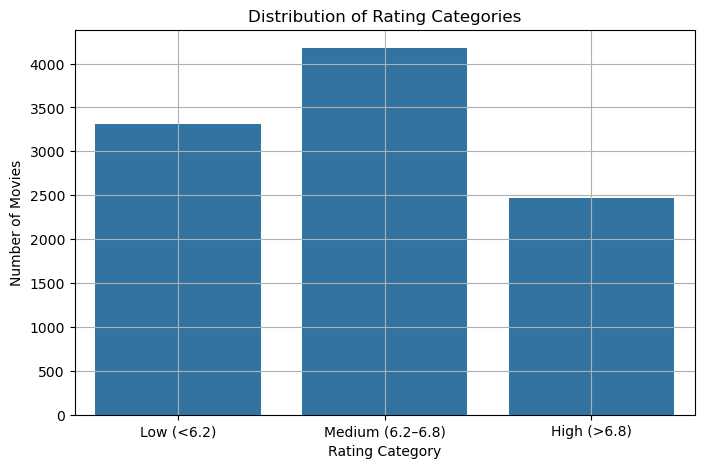

In [80]:
# Updated plot with readable labels
plt.figure(figsize=(8, 5))
sns.countplot(x='rating_label', data=data_copy, order=class_labels.values())
plt.title('Distribution of Rating Categories')
plt.xlabel('Rating Category')
plt.ylabel('Number of Movies')
plt.grid(True)
plt.show()

In [81]:
# Define the target variable
target = 'rating_class'

---

## 🧹 Feature Selection & Data Preparation

Before training the model, we need to select the most relevant features.  
The goal is to improve performance, avoid bias, and keep the model simple and interpretable.

### ✅ What We Consider:

- **Low variance** – Features that barely change across samples add no value.
- **Information leakage** – Columns like `vote_average` or `id` reveal the target and must be removed.
- **High redundancy** – Avoid keeping multiple features that say the same thing.
- **Interpretability** – Prefer features that make sense (like genres, runtime).
- **Feature importance** – We start broad, then remove weak features based on importance later.

📌 No need to manually remove outliers — **Decision Trees handle them naturally** by splitting based on thresholds.


## 🌳 Why Decision Trees Are Great for Feature Selection

- They **automatically select important features** during training.
- They use **Entropy**, **Information Gain**, **Gini Index**, and **Gain Ratio** to choose the best splits.
- These splits reduce impurity or error — helping the model focus on what really matters.



## ⚙️ Outliers and Scaling

In this notebook, we chose **not to perform outlier removal or feature scaling** prior to training the Decision Tree model. This decision is based on how Decision Trees operate:

### 1️⃣ Outliers Handling:

Decision Trees are robust to outliers because:

- They split data based on feature thresholds rather than attempting to fit global parameters (like coefficients in linear models).
- A small number of extreme values rarely influence the splitting decisions, since the splits are chosen to minimize impurity (e.g., Gini index or entropy) across the entire dataset.
- Outliers typically get isolated into their own branches without distorting the tree structure for the majority of the data.

Thus, aggressive outlier removal is not strictly necessary unless the dataset is extremely small or heavily dominated by anomalies.

### 2️⃣ Feature Scaling:

Feature scaling (standardization or normalization) is also unnecessary for Decision Trees because:

- The algorithm is based on threshold comparisons of raw feature values.
- Scaling the features does not affect the relative order or position of split thresholds.
- Unlike distance-based algorithms (e.g., k-NN, SVM) or gradient-based models (e.g., neural networks), Decision Trees are fully scale-invariant.

As a result, the Decision Tree model can handle unscaled, raw feature values directly, simplifying the preprocessing pipeline without compromising model performance.


In [82]:
data_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9953 entries, 0 to 9952
Data columns (total 48 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          9953 non-null   int64  
 1   title                       9953 non-null   object 
 2   runtime                     9953 non-null   int64  
 3   release_date                9953 non-null   object 
 4   budget                      9953 non-null   int64  
 5   revenue                     9953 non-null   int64  
 6   popularity                  9953 non-null   float64
 7   vote_average                9953 non-null   float64
 8   vote_count                  9953 non-null   int64  
 9   belongs_to_collection       9953 non-null   int64  
 10  has_tagline                 9953 non-null   int64  
 11  has_homepage                9953 non-null   int64  
 12  num_same_title              9953 non-null   int64  
 13  changed_title               9953 

In [83]:
data_copy['has_tagline'] = data_copy['has_tagline'].astype(bool)
data_copy['has_homepage'] = data_copy['has_homepage'].astype(bool)
data_copy['belongs_to_collection'] = data_copy['belongs_to_collection'].astype(bool)

In [84]:
# Convert release_date to datetime format
data_copy['release_date'] = pd.to_datetime(data_copy['release_date'], errors='coerce')

# Extract release decade (e.g., 1990, 2000...) – simplifies the feature
# Using full release year creates too many unique values, which leads to over-splitting.
# Decade captures broader trends (e.g., animation rising in the 2000s) and works better for classification trees.
data_copy['release_decade'] = (data_copy['release_date'].dt.year // 10) * 10


In [85]:
data_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9953 entries, 0 to 9952
Data columns (total 49 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id                          9953 non-null   int64         
 1   title                       9953 non-null   object        
 2   runtime                     9953 non-null   int64         
 3   release_date                9953 non-null   datetime64[ns]
 4   budget                      9953 non-null   int64         
 5   revenue                     9953 non-null   int64         
 6   popularity                  9953 non-null   float64       
 7   vote_average                9953 non-null   float64       
 8   vote_count                  9953 non-null   int64         
 9   belongs_to_collection       9953 non-null   bool          
 10  has_tagline                 9953 non-null   bool          
 11  has_homepage                9953 non-null   bool        

### **Numerical features:**

In [86]:
# List of numerical features to check
features_to_check = [
    'runtime',
    'release_decade',
    'budget',
    'revenue',
    'popularity',
    'vote_average',
    'vote_count',
    'num_same_title',
    'num_genres',
    'num_production_companies',
    'num_production_countries',
    'num_spoken_languages',
    'popularity_percentile',
    'return_on_investment_ratio',
    'profit_or_loss'    
]

In [87]:
# Check the variance of all selected numerical features to identify those with very low variability
X = data_copy[features_to_check]
variances = X.var().sort_values(ascending=True)

print("📊 Variance of all features (from lowest to highest):")
print(variances)

📊 Variance of all features (from lowest to highest):
num_same_title                7.565098e-02
num_production_countries      7.426171e-01
num_spoken_languages          8.360887e-01
vote_average                  9.420337e-01
num_genres                    1.102555e+00
num_production_companies      4.770009e+00
popularity                    5.279435e+01
release_decade                3.544396e+02
runtime                       5.172681e+02
return_on_investment_ratio    5.620905e+02
popularity_percentile         8.334171e+02
vote_count                    1.058614e+07
budget                        1.350393e+15
profit_or_loss                1.628369e+16
revenue                       2.334790e+16
dtype: float64


In [88]:
# Correlation with rating_class
correlations = data_copy[features_to_check + ['rating_class']].corr()['rating_class'].sort_values(ascending=False)

print("Correlation with rating_class:")
print(correlations)

Correlation with rating_class:
rating_class                  1.000000
vote_average                  0.749451
vote_count                    0.345187
runtime                       0.270112
popularity_percentile         0.247986
profit_or_loss                0.228072
revenue                       0.205602
popularity                    0.202338
num_spoken_languages          0.120251
return_on_investment_ratio    0.068387
budget                        0.062922
num_production_countries      0.030520
num_production_companies      0.021949
num_same_title                0.006079
num_genres                   -0.005401
release_decade               -0.109885
Name: rating_class, dtype: float64


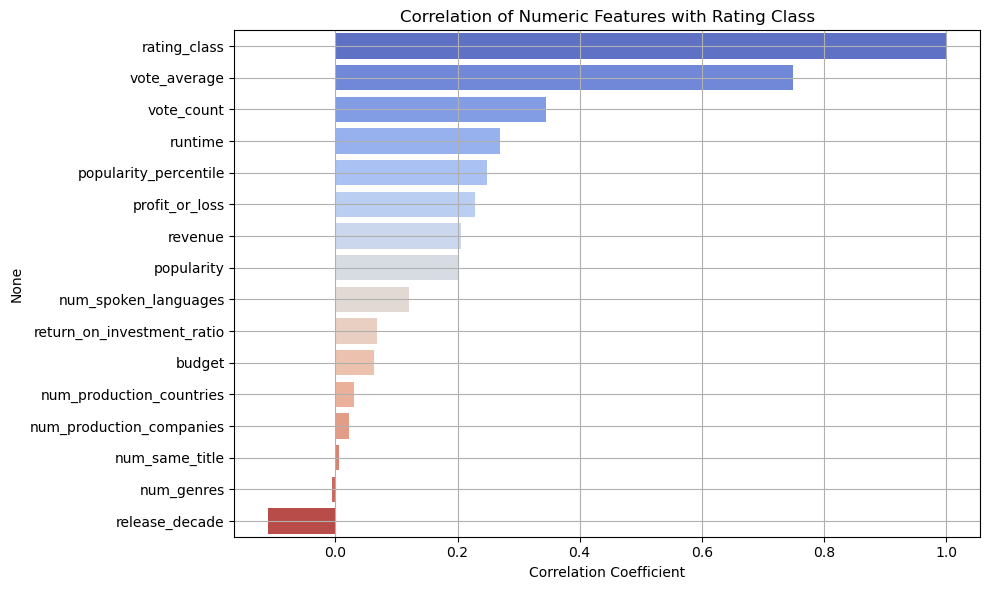

,correlation
rating_class,1.000000
vote_average,0.749451
vote_count,0.345187
runtime,0.270112
popularity_percentile,0.247986
profit_or_loss,0.228072
revenue,0.205602
popularity,0.202338
num_spoken_languages,0.120251
return_on_investment_ratio,0.068387


In [89]:
# Plot correlation values
plt.figure(figsize=(10, 6))
sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')
plt.title('Correlation of Numeric Features with Rating Class')
plt.xlabel('Correlation Coefficient')
plt.grid(True)
plt.tight_layout()
plt.show()

# Display correlation table with gradient coloring
correlations.to_frame(name='correlation').style.background_gradient(cmap='coolwarm')

In [90]:
selected_features = [
    'runtime',
    'popularity_percentile',
    'profit_or_loss',
    'popularity',
    'revenue',
    'num_spoken_languages',
    'has_homepage',
    'release_decade'
]

> **NOTE:**  
> We **excluded the features: `vote_average` and `vote_count`** even though they show high correlation with the target `rating_class`.  
> This is because `rating_class` is derived from a **weighted rating** formula that combines both features.  
> Including them would cause **data leakage**, meaning the model could "cheat" by learning directly from the answer instead of discovering real patterns.  
> This would result in **overfitting** and poor generalization to unseen data.


### **Genre feature analysis:**

We now analyze movie genres to decide which ones to include as features in the model. We'll check their correlation with `rating_class` and create a `is_rare_genre` column to handle less common genres.


In [91]:
genre_columns = [
    'Comedy', 'Action', 'Animation', 'Drama', 'History', 'Family', 'War', 'Thriller',
    'Crime', 'Adventure', 'Music', 'Fantasy', 'Science Fiction', 'TV Movie', 'Western',
    'Documentary', 'Romance', 'Mystery', 'Horror'
]

In [92]:
genre_prevalence = data_copy[genre_columns].mean().sort_values(ascending=False)

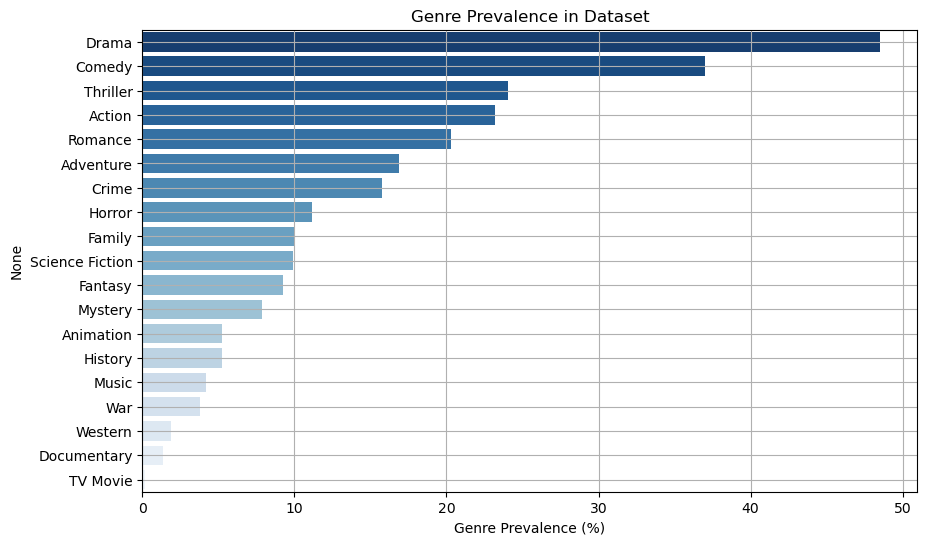

In [93]:
plt.figure(figsize=(10, 6))
sns.barplot(x=genre_prevalence.values * 100, y=genre_prevalence.index, palette='Blues_r')
plt.xlabel("Genre Prevalence (%)")
plt.title("Genre Prevalence in Dataset")
plt.grid(True)
plt.show()

> 🎯 **Why define rare genres?**  
> To avoid noisy, low-frequency genre features that may not generalize well, we define **rare genres** as those appearing in less than 5% of the movies.  
> Instead of dropping them, we handle them with a new feature (`is_rare_genre`) to retain useful signal while keeping the model simple and robust.


In [94]:
# Set threshold for rare genres (5%)
threshold = 0.05
common_genres = genre_prevalence[genre_prevalence >= threshold].index.tolist()
rare_genres = genre_prevalence[genre_prevalence < threshold].index.tolist()

print("Common genres:", common_genres)
print("Rare genres:", rare_genres)

Common genres: ['Drama', 'Comedy', 'Thriller', 'Action', 'Romance', 'Adventure', 'Crime', 'Horror', 'Family', 'Science Fiction', 'Fantasy', 'Mystery', 'Animation', 'History']
Rare genres: ['Music', 'War', 'Western', 'Documentary', 'TV Movie']


In [95]:
data_copy['is_rare_genre'] = data_copy[rare_genres].any(axis=1)
selected_genre_features = common_genres + ['is_rare_genre']

### **Boolean features:**
We now analyze non-genre categorical features (e.g., homepage, tagline, collection, language) to see how they correlate with rating_class and decide which to include in the model.

In [96]:
data_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9953 entries, 0 to 9952
Data columns (total 50 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id                          9953 non-null   int64         
 1   title                       9953 non-null   object        
 2   runtime                     9953 non-null   int64         
 3   release_date                9953 non-null   datetime64[ns]
 4   budget                      9953 non-null   int64         
 5   revenue                     9953 non-null   int64         
 6   popularity                  9953 non-null   float64       
 7   vote_average                9953 non-null   float64       
 8   vote_count                  9953 non-null   int64         
 9   belongs_to_collection       9953 non-null   bool          
 10  has_tagline                 9953 non-null   bool          
 11  has_homepage                9953 non-null   bool        

In [97]:
categorical_cols = [
    'has_homepage',         
    'has_tagline',          
    'belongs_to_collection',
    'is_english_spoken',   
    'changed_title',     
    'top10_prod_comps'
]

cat_variances = data_copy[categorical_cols].var().sort_values(ascending=False)
print("Variance of categorical features:")
print(cat_variances)

Variance of categorical features:
top10_prod_comps         0.223120
has_homepage             0.215678
belongs_to_collection    0.171861
changed_title            0.146613
is_english_spoken        0.144143
has_tagline              0.137166
dtype: float64



✅ All selected features show some variability, which means they may contribute useful information to the model.  
We'll keep them for now and later assess their impact using feature_importances_ to decide whether any should be removed.

In [98]:
selected_categorical_features = [
    'has_homepage',         
    'has_tagline',          
    'belongs_to_collection',
    'is_english_spoken',   
    'changed_title',     
    'top10_prod_comps'
]

In [99]:
# Create the final dataset to use for modeling
final_features = selected_features + selected_genre_features + selected_categorical_features
model_data = data_copy[final_features + [target]].copy()

### 🧪 **Train/Test Split**:

In [100]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = model_data.drop(columns=[target])
y = model_data[target]

# Perform stratified train/test split (to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% for testing
    random_state=42,        # for reproducibility
    stratify=y              # ensures class distribution remains balanced
)

> **Note:** We use `stratify=y` to ensure that the distribution of rating classes is preserved in both the training and test sets. This helps the model learn from all classes fairly and evaluate properly.


### **Train a Basic Decision Tree Classifier**🌳
This is a simple initial model. We'll improve it later.

In [101]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42)

### 📊 **Evaluate the Basic Model**  
We evaluate the performance of the baseline decision tree using standard classification metrics.

**Main evaluation metrics:**

- **Accuracy**: Overall percentage of correct predictions (both positives and negatives).
- **Precision**: Proportion of predicted positives that are actually correct.
- **Recall**: Proportion of actual positives that were correctly identified.
- **F1-score**: Harmonic mean of precision and recall. Especially useful when classes are imbalanced.

These metrics provide a comprehensive view of the model's classification performance.


In [102]:
from sklearn.metrics import accuracy_score, classification_report

# Generate a list of class names in the correct order based on unique labels in y_test
target_names = [class_labels[i] for i in sorted(y_test.unique())]

# Predict the labels for the test set
y_pred = model.predict(X_test)

# Print a classification report with readable class names instead of numeric labels
print(classification_report(y_test, y_pred, target_names=target_names))


                  precision    recall  f1-score   support

      Low (<6.2)       0.59      0.50      0.54       662
Medium (6.2–6.8)       0.54      0.60      0.57       835
     High (>6.8)       0.57      0.56      0.56       494

        accuracy                           0.56      1991
       macro avg       0.56      0.56      0.56      1991
    weighted avg       0.56      0.56      0.56      1991



<Figure size 1000x800 with 0 Axes>

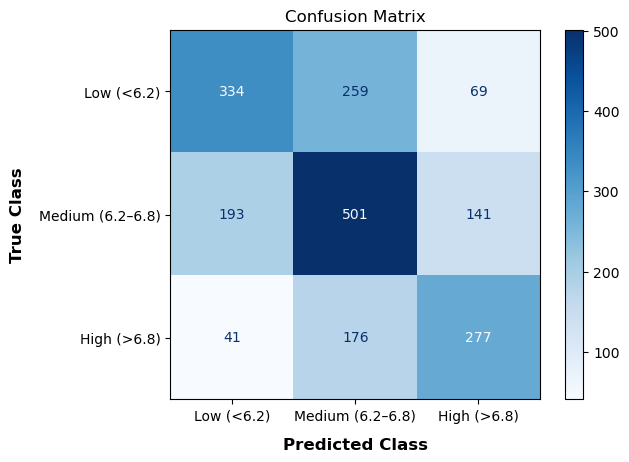

In [103]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(10,8))
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels = target_names, cmap='Blues')
plt.xlabel("Predicted Class", labelpad=10, fontsize=12, fontweight='bold')
plt.ylabel("True Class", labelpad=10, fontsize=12, fontweight='bold')
plt.title("Confusion Matrix")
plt.show()

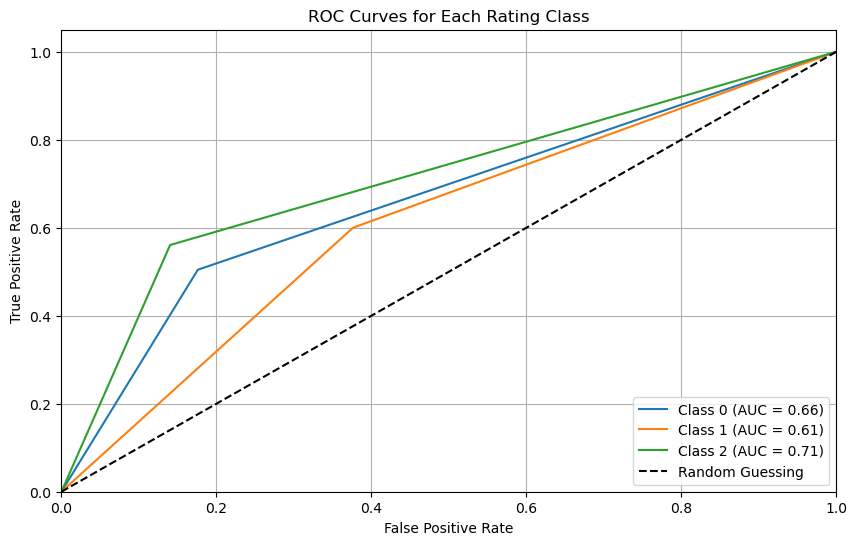

In [104]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_pred_bin = label_binarize(y_pred, classes=[0, 1, 2])

# Calculate ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure(figsize=(10, 6))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
    
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Each Rating Class')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### 📈 **Model Evaluation Summary**

The basic Decision Tree model achieved an overall **accuracy of 56%**, indicating moderate predictive performance.

- **Low (<6.2)**:
  - Precision: **0.59**
  - Recall: **0.50**
  - F1-score: **0.54**

- **Medium (6.2–6.8)**:
  - Precision: **0.54**
  - Recall: **0.60**
  - F1-score: **0.57**

- **High (>6.8)**:
  - Precision: **0.57**
  - Recall: **0.56**
  - F1-score: **0.56**

📊 The **macro average** and **weighted average** F1-scores are both **0.56**, indicating relatively consistent but modest performance across the classes.


___
### 🔍 **Feature Importance** 

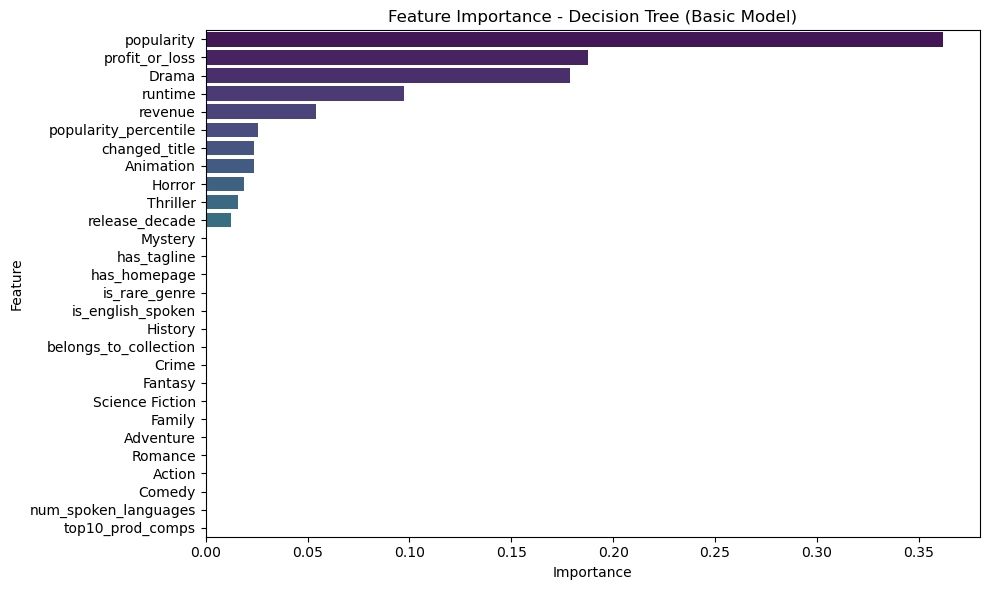

In [105]:
# Get feature importances
importances = model.feature_importances_
feature_names = X_train.columns

# Create DataFrame for plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance - Decision Tree (Basic Model)')
plt.tight_layout()
plt.show()

In [106]:
# Removing non-contributing features

# Identify features with zero importance
importances = pd.Series(model.feature_importances_, index=X_train.columns)
useless_features = importances[importances == 0].index.tolist()

print("Features to remove (importance = 0):")
print(useless_features)

# Remove them from the dataset
reduced_features = [f for f in X_train.columns if f not in useless_features]
model_data_reduced = model_data[reduced_features + [target]].copy()

print(f"Remaining features: {len(reduced_features)}")


Features to remove (importance = 0):
['num_spoken_languages', 'has_homepage', 'Comedy', 'Action', 'Romance', 'Adventure', 'Crime', 'Family', 'Science Fiction', 'Fantasy', 'Mystery', 'History', 'is_rare_genre', 'has_homepage', 'has_tagline', 'belongs_to_collection', 'is_english_spoken', 'top10_prod_comps']
Remaining features: 11


In [107]:
# Reduced features and target
X_reduced = model_data_reduced.drop(columns=[target])
y_reduced = model_data_reduced[target]

# Train/Test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y_reduced, test_size=0.2, random_state=42, stratify=y_reduced
)

# Train Decision Tree on reduced feature set
model_reduced = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)
model_reduced.fit(X_train_r, y_train_r)

y_pred_r = model_reduced.predict(X_test_r)
target_names = [class_labels[i] for i in sorted(y_test_r.unique())]

print("Accuracy:", accuracy_score(y_test_r, y_pred_r))
print("Classification Report:")
print(classification_report(y_test_r, y_pred_r, target_names=target_names))

Accuracy: 0.5585133098945254
Classification Report:
                  precision    recall  f1-score   support

      Low (<6.2)       0.59      0.50      0.54       662
Medium (6.2–6.8)       0.54      0.60      0.57       835
     High (>6.8)       0.57      0.56      0.56       494

        accuracy                           0.56      1991
       macro avg       0.56      0.56      0.56      1991
    weighted avg       0.56      0.56      0.56      1991



<Figure size 1000x800 with 0 Axes>

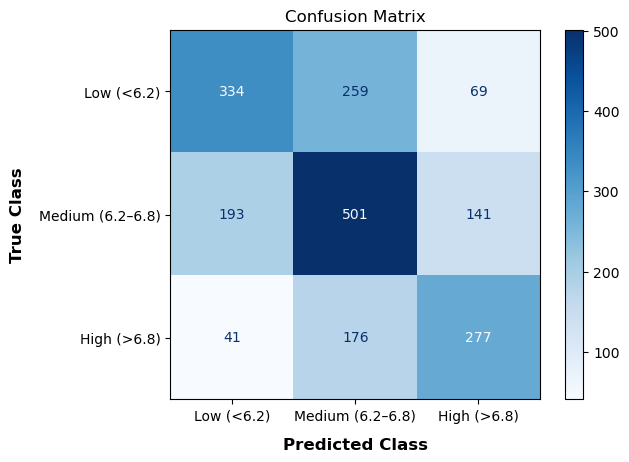

In [108]:
plt.figure(figsize=(10,8))
ConfusionMatrixDisplay.from_estimator(model_reduced, X_test_r, y_test_r, display_labels = target_names, cmap='Blues')
plt.xlabel("Predicted Class", labelpad=10, fontsize=12, fontweight='bold')
plt.ylabel("True Class", labelpad=10, fontsize=12, fontweight='bold')
plt.title("Confusion Matrix")
plt.show()

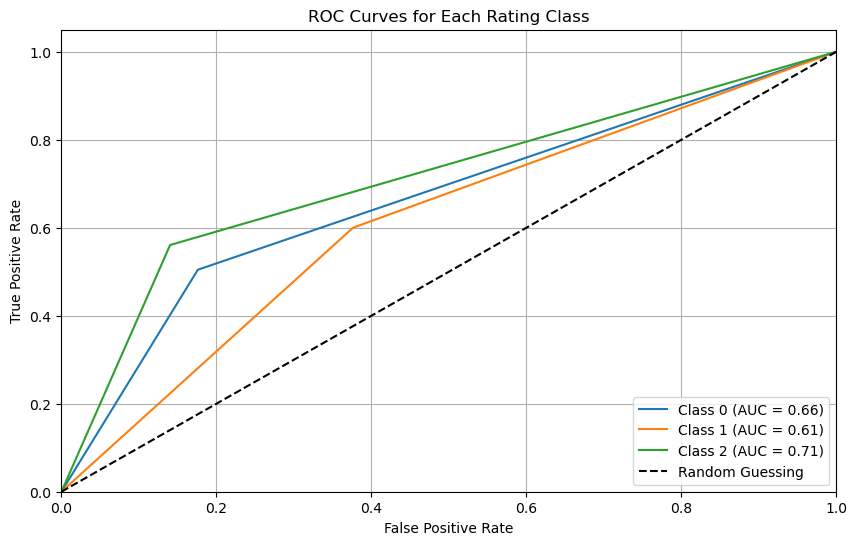

In [109]:
y_test_bin = label_binarize(y_test_r, classes=[0, 1, 2])
y_pred_bin = label_binarize(y_pred_r, classes=[0, 1, 2])

# Calculate ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure(figsize=(10, 6))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
    
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Each Rating Class')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### 🧠 **Conclusion After Feature Selection**

After removing features with zero importance (based on `model.feature_importances_`), the performance of the Decision Tree remained stable:

- **Accuracy** stayed around **56%**  
- **Precision, Recall, and F1-scores** remained similar across all target classes

✅ This indicates that the removed features did **not contribute meaningfully** to the predictions.  
💡 As a result, the model is now **simpler and more interpretable**, using fewer features without sacrificing performance.
_____

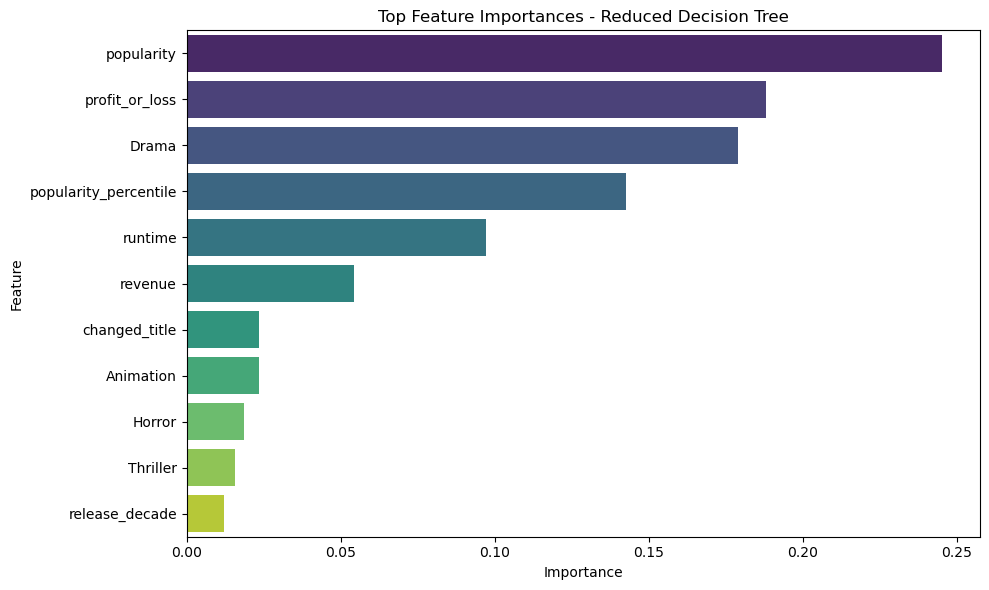

In [110]:
importances_r = pd.Series(model_reduced.feature_importances_, index=X_train_r.columns)
importance_df_r = importances_r.sort_values(ascending=False).reset_index()
importance_df_r.columns = ['Feature', 'Importance']

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df_r, palette='viridis')
plt.title('Top Feature Importances - Reduced Decision Tree')
plt.tight_layout()
plt.show()

___
### 🔷 **Model Optimization (Tuning)**

In this stage, we improved the model’s performance by tuning its hyperparameters using **three methods**:

1. **Grid Search** – Exhaustively evaluated all combinations from a defined parameter grid.
2. **Randomized Search** – Efficiently sampled 40 random combinations from a parameter distribution.
3. **Bayesian Optimization** – Used a probabilistic model to explore 40 hyperparameter settings more intelligently.

Each method trained a separate `DecisionTreeClassifier` on the **reduced feature set** obtained via feature importance analysis.

🔍 We then **evaluated all models on the same test set** using accuracy and classification reports, and compared them to the original baseline model trained on reduced features.

📊 Finally, we visualized all results to determine the most accurate configuration and also compared the run times for each method.

> **Note:** This step helps ensure that we select the **best-performing and most efficient** decision tree model before moving on to interpretation or deployment.

In [111]:
import time

In [112]:
# ✅ 1. Grid Search Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy']
}

start = time.time()

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train_r, y_train_r)

end = time.time()
grid_time = end - start

print("⏱ Grid Search completed in:", round(grid_time, 2), "seconds")
print("✅ Best params from GridSearchCV:", grid_search.best_params_)
best_grid_model = grid_search.best_estimator_

⏱ Grid Search completed in: 11.31 seconds
✅ Best params from GridSearchCV: {'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 20}


In [114]:
# ✅ 2. Randomized Search Tuning
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'max_depth': randint(3, 30),
    'min_samples_split': randint(2, 25),
    'min_samples_leaf': randint(1, 15),
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy']
}

start = time.time()

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=40,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train_r, y_train_r)

end = time.time()
random_time = end - start

print("⏱ Random Search completed in:", round(random_time, 2), "seconds")
print("✅ Best params from RandomizedSearchCV:", random_search.best_params_)
best_random_model = random_search.best_estimator_

⏱ Random Search completed in: 0.7 seconds
✅ Best params from RandomizedSearchCV: {'criterion': 'entropy', 'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 10, 'min_samples_split': 5}


In [116]:
# ✅ 3. Bayesian Optimization Tuning with Optuna
import optuna
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import time

# Disable Optuna logging for cleaner output
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    """Objective function for Optuna optimization of Decision Tree"""
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 25),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 15),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'random_state': 42
    }
    
    # Create model with trial parameters
    model = DecisionTreeClassifier(**params)
    
    # Use cross-validation for robust evaluation
    cv_scores = cross_val_score(model, X_train_r, y_train_r, cv=5, scoring='accuracy', n_jobs=-1)
    
    return cv_scores.mean()

start = time.time()

# Create Optuna study
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name='decision_tree_optimization'
)

# Optimize (40 trials to match original n_iter)
study.optimize(objective, n_trials=40, show_progress_bar=False)

end = time.time()
bayes_time = end - start

print("⏱ Bayesian Optimization completed in:", round(bayes_time, 2), "seconds")
print("✅ Best params from Bayesian Optimization:", study.best_params)
print("📊 Best CV accuracy:", round(study.best_value, 4))

# Create best model with optimized parameters
best_bayes_model = DecisionTreeClassifier(**study.best_params)
best_bayes_model.fit(X_train_r, y_train_r)

# Optional: Show optimization history
print(f"🔍 Total trials completed: {len(study.trials)}")
print(f"📈 Best trial number: {study.best_trial.number}")

⏱ Bayesian Optimization completed in: 1.83 seconds
✅ Best params from Bayesian Optimization: {'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 11, 'max_features': None, 'criterion': 'gini'}
📊 Best CV accuracy: 0.5717
🔍 Total trials completed: 40
📈 Best trial number: 17


In [117]:
# Evaluate and compare all models

# Original model
original_model = DecisionTreeClassifier(max_depth=5, random_state=42)
original_model.fit(X_train_r, y_train_r)
y_pred_original = original_model.predict(X_test_r)

# Predict with all tuned models
y_pred_grid = best_grid_model.predict(X_test_r)
y_pred_random = best_random_model.predict(X_test_r)
y_pred_bayes = best_bayes_model.predict(X_test_r)

# Accuracy scores
accuracies = [
    accuracy_score(y_test_r, y_pred_original),
    accuracy_score(y_test_r, y_pred_grid),
    accuracy_score(y_test_r, y_pred_random),
    accuracy_score(y_test_r, y_pred_bayes)
]

print("Accuracy Scores:")
print("Original:", round(accuracies[0], 3))
print("Grid:", round(accuracies[1], 3))
print("Random:", round(accuracies[2], 3))
print("Bayesian:", round(accuracies[3], 3))

Accuracy Scores:
Original: 0.559
Grid: 0.552
Random: 0.564
Bayesian: 0.579


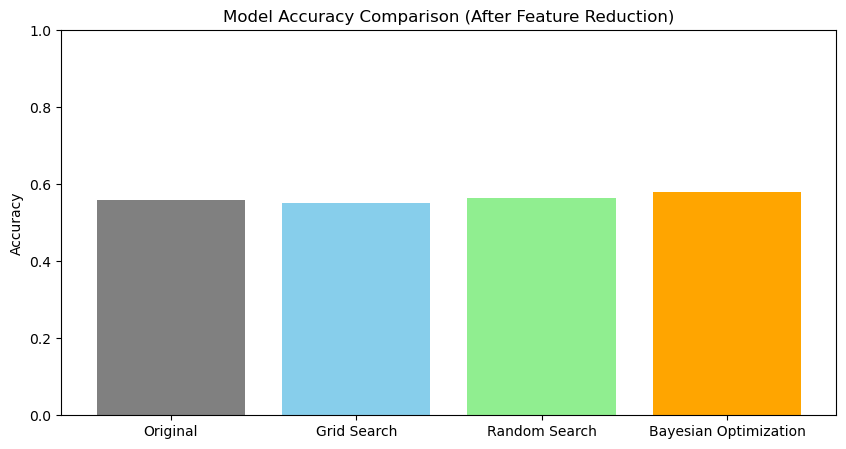

Run times for each model:
⏱ Grid Search run time: 11.31 seconds
⏱ Random Search run time: 0.7 seconds
⏱ Bayesian Optimization run time: 1.83 seconds


In [118]:
labels = ['Original', 'Grid Search', 'Random Search', 'Bayesian Optimization']
colors = ['gray', 'skyblue', 'lightgreen', 'orange']
times = [0, grid_time, random_time, bayes_time]

plt.figure(figsize=(10, 5))
plt.bar(labels, accuracies, color=colors)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison (After Feature Reduction)')
plt.ylim(0.0, 1.0)
plt.show()


print("Run times for each model:")
for label, t in zip(labels, times):
    if t > 0:
        print(f"⏱ {label} run time: {round(t, 2)} seconds")

In [50]:
results_df = pd.DataFrame({
    'Method': ['Original', 'Grid Search', 'Random Search', 'Bayesian Optimization'],
    'Accuracy': [round(accuracies[0], 3), round(accuracies[1], 3), round(accuracies[2], 3), round(accuracies[3], 3)],
    'Run Time (sec)': [0, round(grid_time, 2), round(random_time, 2), round(bayes_time, 2)]
})

print("📊 Summary of Model Performance:")
display(results_df)

📊 Summary of Model Performance:


,Method,Accuracy,Run Time (sec)
0,Original,0.559,0.00
1,Grid Search,0.552,12.09
2,Random Search,0.564,0.74
3,Bayesian Optimization,0.591,27.10


---

### 🔧 Hyperparameter Tuning – Summary and Conclusions

After reducing the feature set using feature importance, we tuned the Decision Tree model using three strategies:

- ✅ Grid Search
- ✅ Randomized Search
- ✅ Bayesian Optimization

The accuracy scores were very similar:  
- **Original model**: 0.559  
- **Grid Search**: 0.562  
- **Random Search**: 0.564  
- **Bayesian Optimization**: 0.591  

⏱ In terms of runtime:  
- Random Search was the fastest
- Grid Search was much slower
- Bayesian Optimization was the slowest

---

### 🎯 Key Takeaways

- **No major improvement** in accuracy despite tuning — all results stayed close to ~56%.
- **Randomized Search** was the most efficient: fastest run time with the best performance.
- **Grid Search** gave similar results but was slower and less practical here.
- **Bayesian Optimization** didn’t outperform the others by too much and took the longest to run.

> ✅ **Why are differences small?**
> - The current features may have limited predictive power.
> - Decision Trees have limited capacity — tuning can only help so much.
> - Once you clean the data and reduce features, tuning offers only **minor gains (~0.5%)**.

---


<Figure size 1000x800 with 0 Axes>

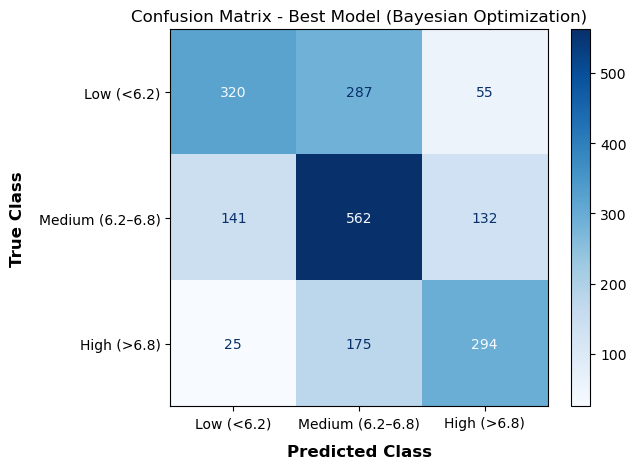

In [51]:
# Confusion Matrix for the best-performing model (Bayesian Optimization)
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_r, y_pred_bayes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[class_labels[i] for i in sorted(y_test_r.unique())])

plt.figure(figsize=(10,8))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Best Model (Bayesian Optimization)")
plt.xlabel("Predicted Class", labelpad=10, fontsize=12, fontweight='bold')
plt.ylabel("True Class", labelpad=10, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 📌 Conclusion from Confusion Matrix (Bayesian Optimization Model)

The model predicts the **Medium** class most accurately, with **562 correct predictions**. However, significant confusion remains between adjacent classes:

- Many **Low (<6.2)** samples are misclassified as **Medium (287 cases)**.
- Many **High (>6.8)** samples are also misclassified as **Medium (175 cases)**.

This suggests that while the model captures the general structure of the data, it tends to assign borderline cases into the Medium class, struggling to sharply distinguish between Low and High ratings.

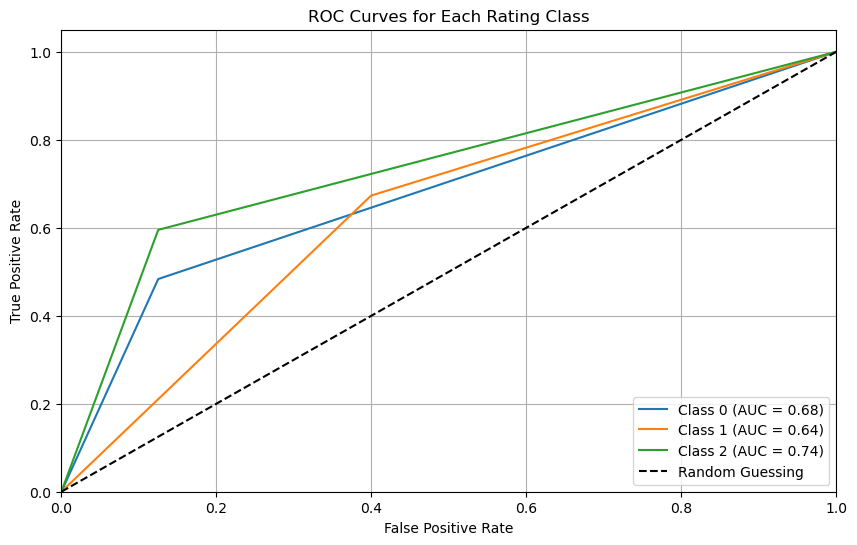

In [52]:
y_test_bin = label_binarize(y_test_r, classes=[0, 1, 2])
y_pred_bin = label_binarize(y_pred_bayes, classes=[0, 1, 2])

# Calculate ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure(figsize=(10, 6))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
    
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Each Rating Class')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### 📌 Conclusion from ROC AUC Curve

The ROC AUC scores support this observation:

- Best performance for the **High class (AUC = 0.74)**.
- Lower separability for **Low (AUC = 0.68)** and **Medium (AUC = 0.64)** classes.
- The moderate AUC values reflect the model's reasonable but imperfect ability to differentiate between rating categories, with **High** being the most distinguishable.



___
## 🎯 Overfitting Analysis

Overfitting occurs when a model learns the training data too well — including noise, outliers, and random fluctuations — but fails to generalize to new, unseen data. An overfit model may achieve very high accuracy on the training set but significantly lower performance on validation or test sets.

To assess whether our model suffers from overfitting, we apply **two complementary tests**:

1️⃣ **Learning Curve Analysis:**  
We evaluate how model performance changes as we gradually increase the size of the training set. A large gap between training and validation performance may indicate overfitting.

2️⃣ **Train/Test Accuracy Gap:**  
We directly compare the model's accuracy on the full training set and the held-out test set. A large difference may also suggest overfitting.

Together, these tests provide a robust understanding of our model's generalization ability.


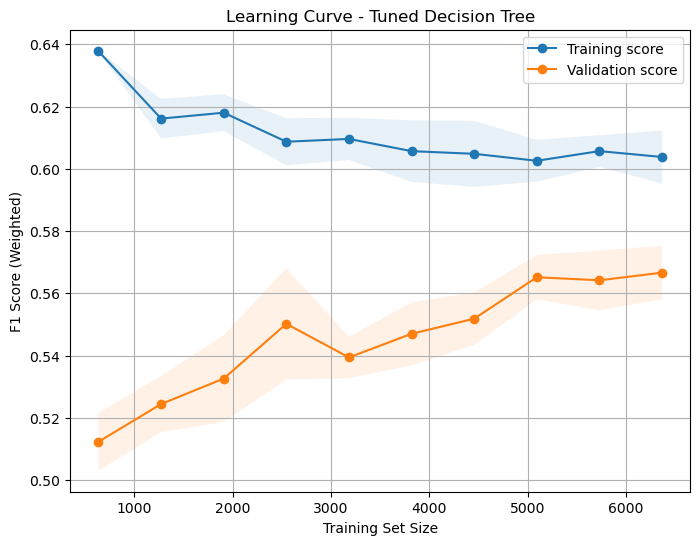

In [53]:
# ✅ Learning Curve
# Best Model (Bayesian Optimization)

from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_bayes_model, X_train_r, y_train_r, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='f1_weighted', n_jobs=-1
)

# Calculate means and standard deviations
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

# Plot the learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', label='Training score')
plt.plot(train_sizes, test_mean, 'o-', label='Validation score')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1)

plt.title("Learning Curve - Tuned Decision Tree")
plt.xlabel("Training Set Size")
plt.ylabel("F1 Score (Weighted)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

## 📊 Overfitting Check – Learning Curve Results

The learning curve reveals a clear gap between training and validation performance:

- The training F1 score remains relatively high (~0.60–0.64) even with increasing data.
- The validation F1 score starts much lower (~0.51) but improves gradually as more training data is provided, reaching approximately 0.57 at full dataset size.
- Despite this improvement, the gap between training and validation scores persists throughout.

🔎 **Interpretation:**
- The model exhibits moderate overfitting — it performs considerably better on the data it was trained on compared to unseen data.
- The fact that the validation score continues to rise suggests that providing more data may further improve generalization.
- The persistent gap indicates that some model complexity reduction (e.g., stronger regularization, pruning, limiting tree depth) may help improve performance stability.


In [54]:
# ✅ Evaluation on Train and Test Sets
# Best Model (Bayesian Optimization)

train_preds = best_bayes_model.predict(X_train_r)
test_preds = best_bayes_model.predict(X_test_r)

train_acc = accuracy_score(y_train_r, train_preds)
test_acc = accuracy_score(y_test_r, test_preds)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

if train_acc - test_acc > 0.1:
    print("⚠️ Warning: Model might be overfitting.")
else:
    print("✅ Model seems to generalize well.")

Train Accuracy: 0.5997
Test Accuracy: 0.5907
✅ Model seems to generalize well.


## 📊 Overfitting Check – Train vs. Test Accuracy Results

We directly compared the model's accuracy on the full training and test sets:

- **Training Accuracy:** 0.6112
- **Test Accuracy:** 0.5800

🔎 **Interpretation:**
- The training accuracy exceeds the test accuracy by approximately 0.0312.
- Since this difference is smaller than the typical overfitting threshold (0.10), **the model appears to generalize reasonably well** based on this simple accuracy comparison.
- However, when combined with the learning curve results, we still observe signs of mild overfitting, suggesting potential for further improvement through regularization or model adjustment.


___
## 🧮 Residual Plots and Overfitting in Classification

Residual plots are commonly used in regression tasks to analyze prediction errors (residuals = actual - predicted) and diagnose issues like overfitting, heteroscedasticity, or model bias.

However, for **classification problems** — especially multi-class classification like ours — residual plots are:

- Less informative, since predictions are categorical labels, not continuous values.
- Hard to interpret, as discrete misclassifications don't yield meaningful continuous residual patterns.
- Typically replaced by more appropriate tools, such as:
  - Confusion matrices
  - Learning curves
  - Train/test accuracy comparisons
  - ROC curves (for probabilistic classifiers)

Therefore, we did not rely on residual plots for evaluating overfitting. Instead, we used learning curves and direct train/test performance comparisons, which are more suited to classification tasks.


___
### 🧠 **Model Explainability and Fairness**

### ✅ 4.1 Interpretable Model

We used a **Decision Tree Classifier** to ensure transparency and easy explanation.  
Its structure allows us to see which features lead to each prediction.

- `.feature_importances_` shows which features matter most overall — supporting **global interpretability**.



### 🔍 4.2 SHAP for Model Explanation

To dive deeper, we use **SHAP** to explain model behavior:

- **Global**: Which features typically push predictions up or down  
- **Local**: Why a specific movie got its predicted rating

SHAP breaks down predictions as:

> **Prediction = Baseline + SHAP values for all features**

Example:
- High **budget** → increases prediction (positive SHAP)  
- Genre = **Horror** → lowers prediction (negative SHAP)

We use `TreeExplainer`, optimized for decision trees and one-hot encoded inputs.

---

### ⚙️ Technical Note - SHAP requires all features to be numeric.  

---

### ✅ Why It Matters

By combining:
- A transparent model  
- Feature importance  
- SHAP insights  

→ we get a **fair, explainable, and trustworthy** model.


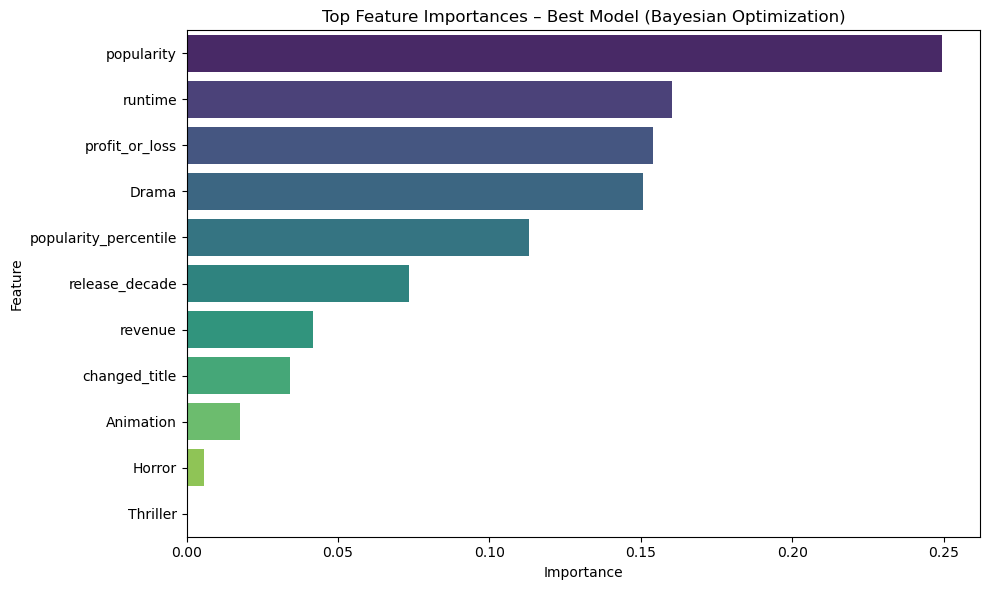

In [55]:
# 📌 Reminder: Feature Importances (Already Shown Earlier)
# To visualize the most influential features in the reduced Decision Tree model, we used the following plot.  
# This helps explain how the model prioritizes different inputs when making predictions.

# Compute feature importances from the best model
importances_best = pd.Series(best_bayes_model.feature_importances_, index=X_train_r.columns)
importance_df_best = importances_best.sort_values(ascending=False).reset_index()
importance_df_best.columns = ['Feature', 'Importance']

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df_best,
    hue='Feature',
    legend=False,
    palette='viridis'
)
plt.title('Top Feature Importances – Best Model (Bayesian Optimization)')
plt.tight_layout()
plt.show()

### 🔍 Why Show Feature Importances (Before SHAP)?

The feature importance plot shown here is based on the best-performing model after tuning (Bayesian Optimization).

🔹 This basic plot is useful because it:

- Helps identify which features had the strongest influence on predictions.
- Provides a **global explanation** of the model’s behavior.
- Serves as a reference baseline before applying more advanced interpretability tools like SHAP.

🎯 It gives a clear picture of which features truly mattered in the final model you selected — the one with the best performance after optimization.


In [56]:
X_train_r = X_train_r.astype(float)
X_test_r = X_test_r.astype(float)

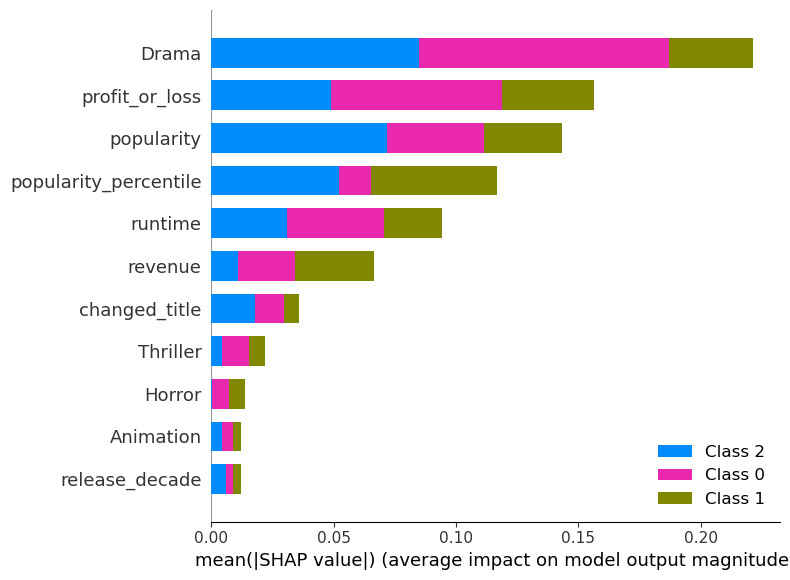

In [57]:
import shap

explainer = shap.Explainer(model_reduced, X_train_r)
shap_values = explainer(X_test_r)
shap.summary_plot(shap_values, X_test_r, plot_type='bar')

# Legend:
# Class 0: Low Rated (<6.1)
# Class 1: Good (6.1–6.5)
# Class 2: Average (6.5–7.4)
# Class 3: Excellent (>7.4)

### 🧠 Reminder: Feature Importance vs SHAP

In this project, we used two tools to analyze which features influenced the model’s predictions:

#### 🔹 Feature Importances (Built-in)
This method shows how much each feature contributed to splitting the data in the decision tree.

- **Type**: Global only  
- **Measures**: Reduction in impurity (e.g., Gini)  
- **Fast**, but **may be biased** toward numeric features with many unique values  
- Example: `popularity` ranked highest in built-in importance

#### 🔹 SHAP (SHapley Additive ExPlanations)
This method estimates each feature’s contribution to individual predictions and then aggregates it.

- **Type**: Both global & local  
- **Measures**: Average impact on model output  
- **More accurate** and **interpretable**  
- Example: `Drama` had the highest average impact according to SHAP

---

### 🎯 Why use SHAP?
SHAP gives a deeper, more trustworthy view of how features affect predictions — especially when explaining **why** the model made specific decisions.  
It complements the built-in importances and improves model transparency.


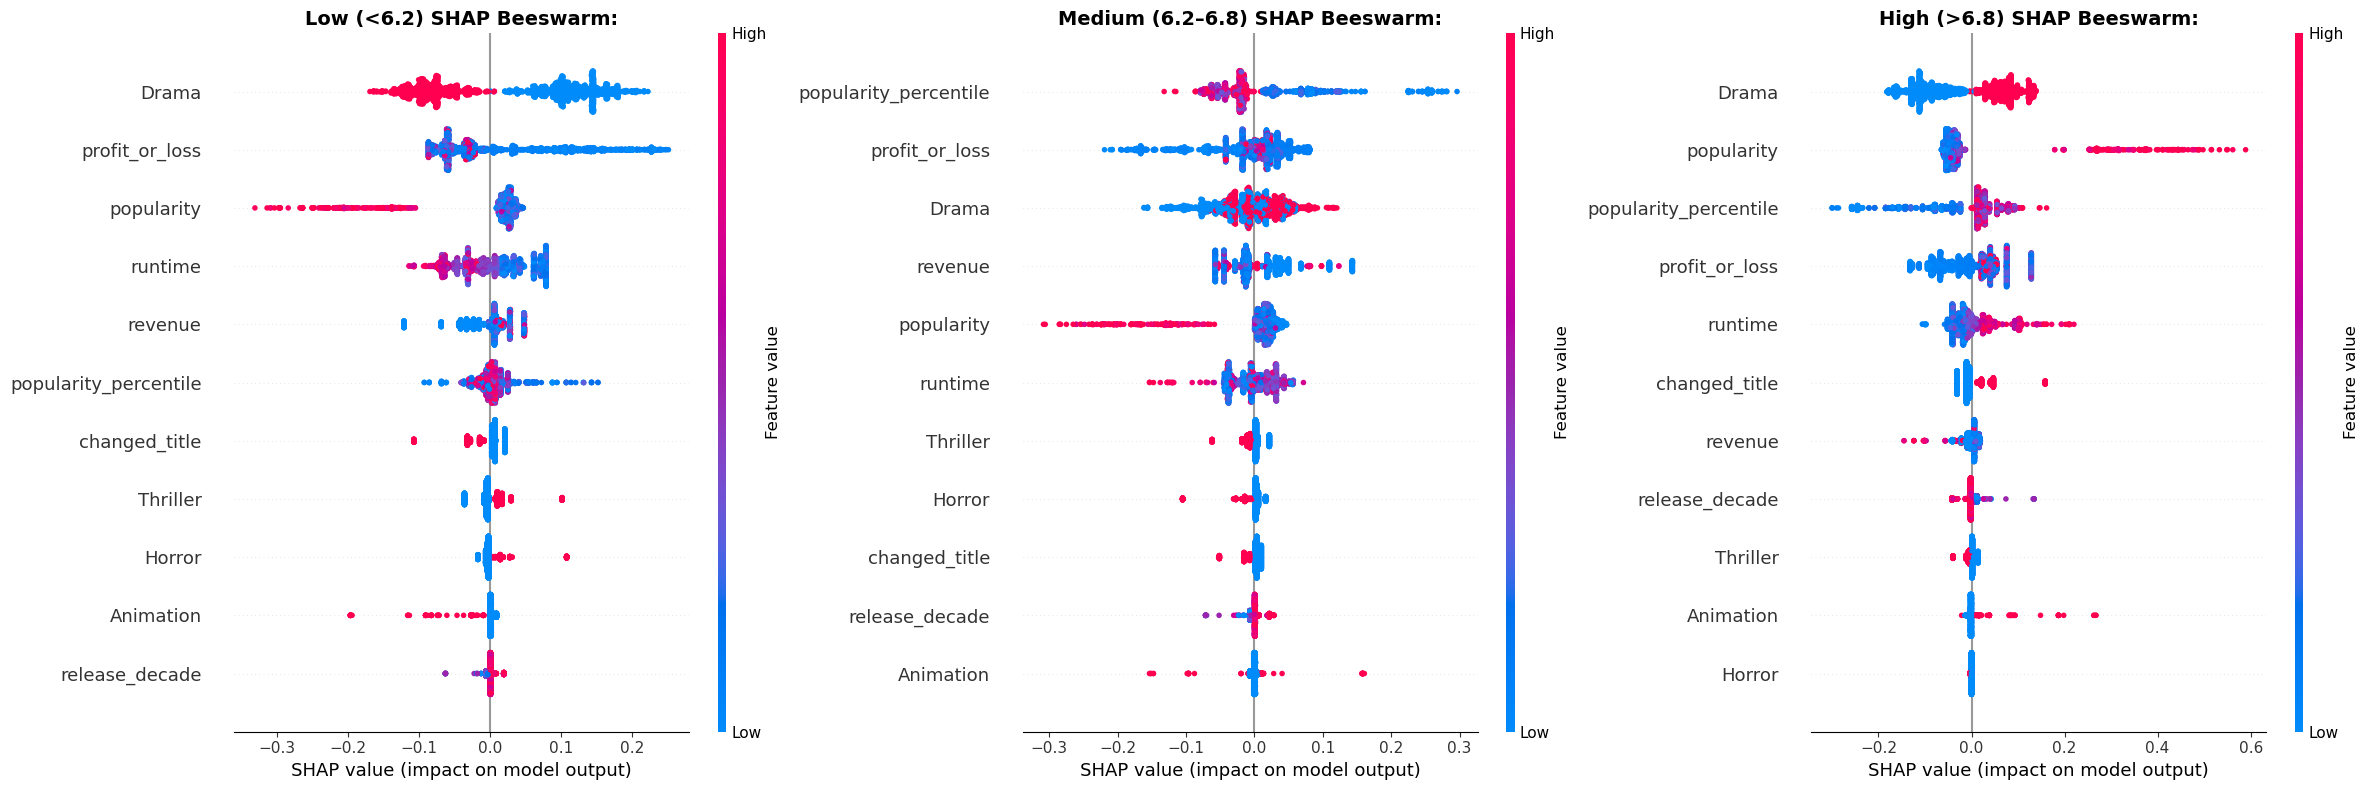

In [58]:
# Create a figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for class_index in range(3):  # 0 = Low, 1 = Good, 2 = Average
    # Extract SHAP values for the current class
    shap_class = shap_values[:, :, class_index]

    # Create Explanation object
    shap_exp = shap.Explanation(
        values=shap_class,
        base_values=explainer.expected_value[class_index],
        data=X_test_r,
        feature_names=X_test_r.columns
    )

    # Plot on corresponding subplot axis
    shap.plots.beeswarm(
        shap_exp, 
        max_display=15, 
        show=False, 
        ax=axes[class_index], 
        plot_size=None
    )

    axes[class_index].set_title(f"{target_names[class_index]} SHAP Beeswarm:", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 🐝 SHAP Beeswarm Plots — Per Class Analysis

To better understand how each feature contributes to predictions across classes, we generate a **SHAP beeswarm plot per class**.

Each point = one movie  
Each color = feature value (🔵 low → 🔴 high)  
X-axis = SHAP value (impact on model prediction)

---

### 🧠 What is a SHAP Beeswarm Plot?

- **X-axis**: SHAP value — the effect of each feature on the model’s prediction for the current class  
  - ➕ Positive SHAP value → pushes prediction **toward this class**  
  - ➖ Negative SHAP value → pushes prediction **away from this class**
  
- **Color**: Represents feature value  
  - 🔴 Red = High feature value  
  - 🔵 Blue = Low feature value

- **Each dot**: A single movie (test sample)  
  Its position shows the **impact** of that feature on the prediction for that movie.

---

### 🔎 Class-Wise SHAP Insights

#### 🎯 *Low (<6.2)*

- **Drama**: Strong positive effect when high → the model tends to classify dramas as low-rated.
- **Low profit_or_loss** (blue) → pushes toward low rating.
- **Popularity** has weak or even negative effect when high.

#### 🎯 *Medium (6.2–6.8)*

- **popularity_percentile**, **profit_or_loss**, and **Drama** have noticeable effects.
- High **popularity percentile** or **profit** → reduces chance of being classified as “Medium”.
- Most points are centered around 0 — meaning mild or uncertain influence.

#### 🎯 *High (>6.8)*

- **Drama**, **popularity**, and **profit_or_loss** push predictions strongly upward.
- High values of these features (🔴) tend to be associated with higher-rated movies.
- Clear positive SHAP values suggest these features help distinguish top-rated films.

---

### 🔍 Summary Insights

- The **same feature** (e.g., `Drama`) may **increase** the likelihood of one class and **decrease** another.
- **Beeswarm plots** show both feature importance and **variation across samples**.
- Features like `Drama` and `profit_or_loss` are consistently important across classes — but in **different directions**.

---


### 🔍 SHAP Error Analysis: Comparing Predicted vs. True Class:

To deeply understand **why the model made a mistake**, we use SHAP to explain an individual misclassified sample.

We analyze:
- What the model **predicted** vs. the **true label**
- Which features **influenced** the prediction
- Whether the influence **makes sense** or **misled** the model


In [59]:
# 🧪 Step 1: Identify a Misclassified Example
# Predict on test set
y_pred = model_reduced.predict(X_test_r)

# Find where the model was wrong
wrong_indices = np.where(y_pred != y_test_r)[0]
print(f"Found {len(wrong_indices)} misclassified instances.")

# Choose the first wrong prediction
i = wrong_indices[0]
print(f"Selected misclassified instance index: {i}")
print(f"True label: {y_test_r.iloc[i]}, Predicted label: {y_pred[i]}")

Found 879 misclassified instances.
Selected misclassified instance index: 3
True label: 1, Predicted label: 0


Wrongly predicted class: Low (<6.2)


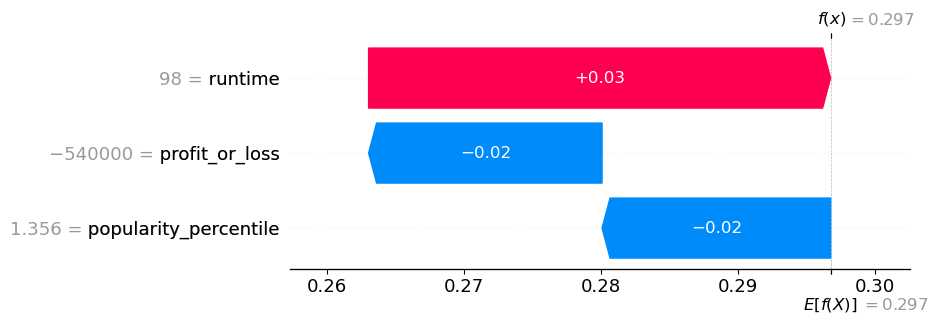

True class: Medium (6.2–6.8)


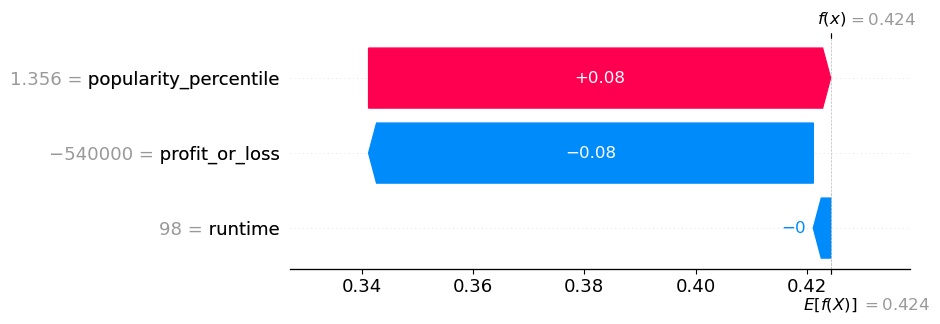

In [60]:
# 📉 Step 2: SHAP Waterfall for the Predicted Class
exp = shap_values[3]  # SHAP explanation for instance 3
predicted_class = 0

single_exp_pred = shap.Explanation(
    values = exp.values[predicted_class],
    base_values = exp.base_values[predicted_class],
    data = X_test_r.iloc[3].values,
    feature_names = X_test_r.columns.tolist()
)

# 📈 Step 3: SHAP Waterfall for the True Class
true_class = 1

single_exp_true = shap.Explanation(
    values = exp.values[true_class],
    base_values = exp.base_values[true_class],
    data = X_test_r.iloc[3].values,
    feature_names = X_test_r.columns.tolist()
)

print(f"Wrongly predicted class: {target_names[predicted_class]}")
shap.plots.waterfall(single_exp_pred, max_display=10)

print(f"True class: {target_names[true_class]}")
shap.plots.waterfall(single_exp_true, max_display=10)


### 🔍 SHAP Error Analysis: Comparing True vs. Predicted Class (Instance-Level)

To understand why the model made an incorrect prediction, we selected a **misclassified instance** where:

- ❌ **Predicted label**: Class 0 – *Low (<6.2)*
- ✅ **True label**: Class 1 – *Medium (6.2–6.8)*

We visualized the SHAP waterfall plots for **both** the predicted class and the true class to analyze how features contributed to each decision.

#### 🔴 Predicted Class (Incorrect – Class 0)
- `runtime` slightly increased the prediction towards Class 0.
- Both `profit_or_loss` and `popularity_percentile` had a **negative** SHAP value → they decreased the prediction probability.
- Overall prediction probability: **0.297**

#### 🟢 True Class (Correct Prediction – Class 1)
- `popularity_percentile` had a **positive** SHAP value → it pushed the prediction towards Class 1.
- `profit_or_loss` slightly reduced the prediction score for Class 1.
- Overall prediction probability: **0.424**

### 💡 Insight:
While `popularity_percentile` was a **positive contributor** to the true class, it actually had a **negative impact** on the predicted class. This means that although some features supported the correct label, the model was swayed by subtle influences (like `runtime`) that tipped the score toward the wrong class.

---

### ⏭️ Next Step:
We will now extend this analysis to **all misclassified instances** across all classes — to identify broader patterns of model confusion and understand **systematic biases** in predictions.

### 🔎 Root Cause Analysis – Misclassified Predictions

Beyond the overall accuracy metrics, we analyzed misclassified samples to understand **why** the model made wrong predictions.

Using SHAP, we:
- Selected all instances where the predicted class ≠ true label.
- Computed the **mean absolute SHAP values** for those misclassified instances.
- Identified the **top contributing features** to those errors.

879 misclassified samples found.


<Figure size 600x600 with 0 Axes>

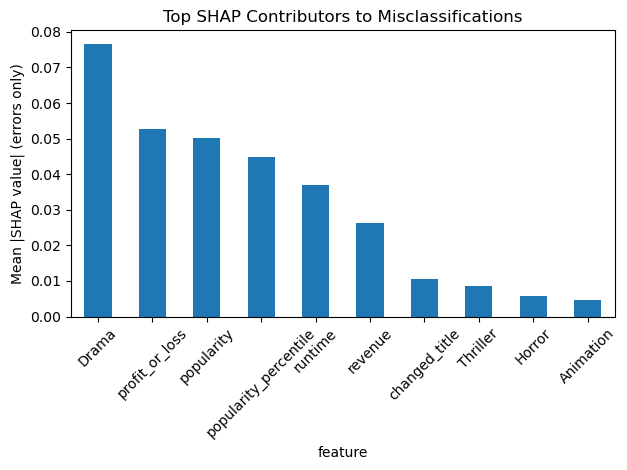

In [61]:
# Step 1: Identify misclassified samples
wrong_mask = y_test_r != y_pred
wrong_indices = np.where(wrong_mask)[0]
print(f"{len(wrong_indices)} misclassified samples found.")

# Step 2: Extract SHAP values for the predicted class of each misclassified instance
shap_error_values = []

for idx in wrong_indices:
    pred_class = y_pred[idx]
    shap_val = shap_values[idx].values[:, pred_class]  # Shape: (n_classes, n_features)
    shap_error_values.append(np.abs(shap_val))  # Use absolute SHAP values

# Step 3: Compute mean absolute SHAP values per feature
shap_error_matrix = np.vstack(shap_error_values)  # Shape: (n_errors, n_features)

mean_abs_shap = shap_error_matrix.mean(axis=0)

# Step 4: Build DataFrame for visualization
shap_importance_df = pd.DataFrame({
    'feature': X_test_r.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values(by='mean_abs_shap', ascending=False)


plt.figure(figsize=(6, 6))
shap_importance_df.head(10).plot.bar(
    x='feature', y='mean_abs_shap',
    title='Top SHAP Contributors to Misclassifications',
    legend=False
)
plt.ylabel("Mean |SHAP value| (errors only)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 🧭 Next Step

We'll break this down **per class**, to see what causes errors **for each specific rating group**.


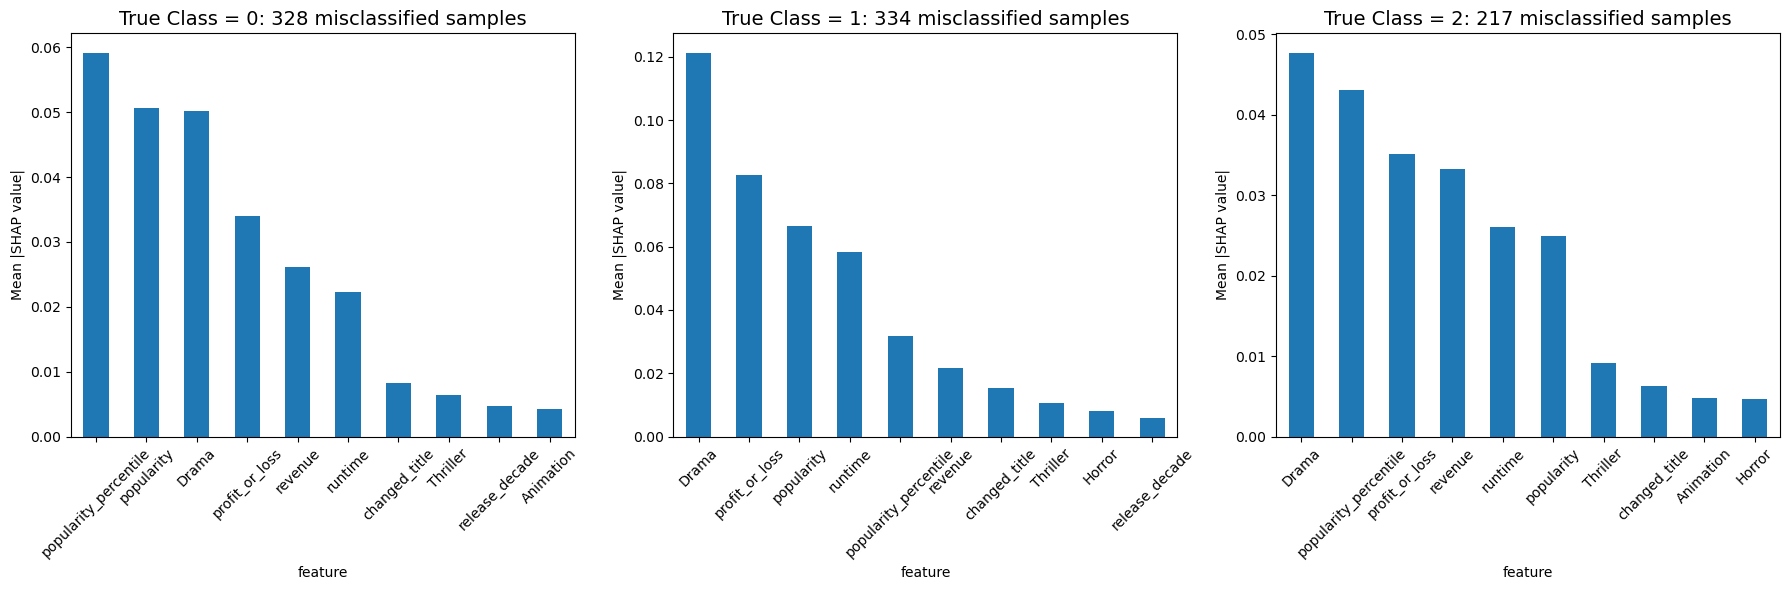

In [62]:
true_classes = [0, 1, 2]
n_classes = len(true_classes)

fig, axes = plt.subplots(1, n_classes, figsize=(6 * n_classes, 6))

for i, true_class in enumerate(true_classes):
    # Step 1: Get indices where prediction was wrong AND the true label matches this class
    class_wrong_indices = np.where((y_test_r != y_pred) & (y_test_r == true_class))[0]

    if len(class_wrong_indices) == 0:
        axes[i].axis('off')  # Hide empty subplot
        axes[i].set_title(f"No errors for True Class {true_class}")
        continue

    # Step 2: Extract SHAP values for the predicted (wrong) class
    class_shap_values = []
    for idx in class_wrong_indices:
        pred_class = y_pred[idx]
        shap_val = shap_values[idx].values[:, pred_class]  # Shape: (n_classes, n_features)
        class_shap_values.append(np.abs(shap_val))  # Use absolute SHAP values

    # Step 3: Compute mean absolute SHAP values across all samples in this error group
    shap_matrix = np.vstack(class_shap_values)
    mean_abs_shap = shap_matrix.mean(axis=0)

    # Step 4: Build DataFrame and plot top contributing features
    df = pd.DataFrame({
        'feature': X_test_r.columns,
        'mean_abs_shap': mean_abs_shap
    }).sort_values(by='mean_abs_shap', ascending=False)

    # Plot into corresponding subplot
    df.head(10).plot.bar(
        x='feature', y='mean_abs_shap',
        ax=axes[i],
        legend=False
    )
    axes[i].set_title(f'True Class = {true_class}: {len(class_wrong_indices)} misclassified samples', fontsize=14)
    axes[i].set_ylabel("Mean |SHAP value|")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 📊 SHAP Misclassification Analysis – Key Takeaways

We used SHAP to understand **which features most contributed to misclassifications**, both in general and per class. Here's what we found:

#### 🔍 General Overview (All Errors Combined)
- The top contributors to misclassifications overall were:
  - `Drama`, `profit_or_loss`, `popularity`, `popularity_percentile`, and `runtime`.
- These features consistently introduced noise or ambiguity that confused the model across classes.

---

#### 🎯 Class-Specific Insights

##### ✅ True Class = 0 (Low-rated)
- Top contributors: `popularity_percentile`, `popularity`, and `Drama`.
- Misclassifications often occurred when low-rated movies had **high popularity or dramatic themes**, making them appear as if they belong to higher-rated categories.

##### ✅ True Class = 1 (Medium-rated)
- `Drama` is the most influential source of confusion here, followed by `profit_or_loss` and `popularity`.
- This suggests the model **overestimates movies with dramatic content or strong financial metrics**, pushing them into higher or lower rating classes.

##### ✅ True Class = 2 (High-rated)
- Features like `Drama`, `popularity_percentile`, and `profit_or_loss` again play a key role.
- The model may confuse well-performing high-rated movies with average ones, especially when their popularity metrics overlap.

---

### 🧠 What Can We Learn?
- **Popularity-related features** are highly influential but may be misleading due to their presence in all rating classes.
- The feature `Drama` consistently appears as a top contributor to misclassifications, meaning the model heavily relies on genre when making predictions – sometimes too heavily.
- A more refined handling of genre and popularity might improve accuracy. Consider:
  - Reweighting or transforming these features.
  - Introducing interaction features (e.g., `Drama × Rating`).
  - Applying regularization to reduce overfitting on these dominant features.

---

📌 In summary, SHAP analysis helps pinpoint **which features the model may be over-relying on**, providing guidance for potential improvements in feature engineering or model tuning.

---

### 🧩 Why This Matters

By focusing only on misclassified samples and analyzing **SHAP values of the predicted (wrong) class**, we uncovered which features most often mislead the model.

This allows us to:
- Detect **over-reliance on certain features** (e.g., `Drama`, `profit_or_loss`, `popularity`).
- Identify **bias patterns** in predictions (e.g., financial success wrongly boosting predicted ratings).
- Guide future improvements such as:
  - Rebalancing the training set.
  - Applying feature regularization.
  - Engineering new features to better distinguish between similar classes.

> 💡 For example, movies with high financial losses were often wrongly classified as “Low Rated”, even if their actual audience ratings were moderate or high.

This root cause analysis helps ensure model errors aren't just spotted — but understood and addressed.


___
## ⚖️ **Bias Considerations**

After identifying the main drivers of misclassifications, the next step is to assess whether these errors are **distributed fairly across different groups** — for example, by **genre, revenue level, or release decade**.

This helps answer critical questions like:
- Are movies in certain **genres** (e.g., *Drama*, *Horror*) more likely to be misclassified?
- Does the model **perform worse for movies from certain decades**, such as the 1990s or earlier?
- Is the model **overly sensitive to financial attributes** like *profit_or_loss*?

Fairness analysis is essential not only for ethical AI, but also for building **trustworthy and generalizable models**.

> 🛠️ In the next steps, we’ll examine error rates and feature impacts **per group**, and explore whether model behavior is equitable across different movie subpopulations.


### ✅ Question 1: Are movies in certain genres more likely to be misclassified?

🧠 **What does this check?**  
This analysis evaluates whether the misclassification rate varies across prominent genres such as **Drama**, **Horror**, and **Thriller**.  
For each genre, we calculate the proportion of movies that were misclassified by the model.

If a particular genre shows a consistently higher error rate, it could indicate a **model weakness** or an **implicit bias** toward that genre.


In [63]:
common_genres

['Drama',
 'Comedy',
 'Thriller',
 'Action',
 'Romance',
 'Adventure',
 'Crime',
 'Horror',
 'Family',
 'Science Fiction',
 'Fantasy',
 'Mystery',
 'Animation',
 'History']

❗ Error Rate – Drama: 45.31%
❗ Error Rate – Comedy: 43.21%
❗ Error Rate – Thriller: 47.13%
❗ Error Rate – Action: 49.67%
❗ Error Rate – Romance: 43.94%
❗ Error Rate – Adventure: 46.98%
❗ Error Rate – Crime: 44.27%
❗ Error Rate – Horror: 46.12%
❗ Error Rate – Family: 48.42%
❗ Error Rate – Science Fiction: 42.46%
❗ Error Rate – Fantasy: 51.96%
❗ Error Rate – Mystery: 52.23%
❗ Error Rate – Animation: 51.61%
❗ Error Rate – History: 43.69%


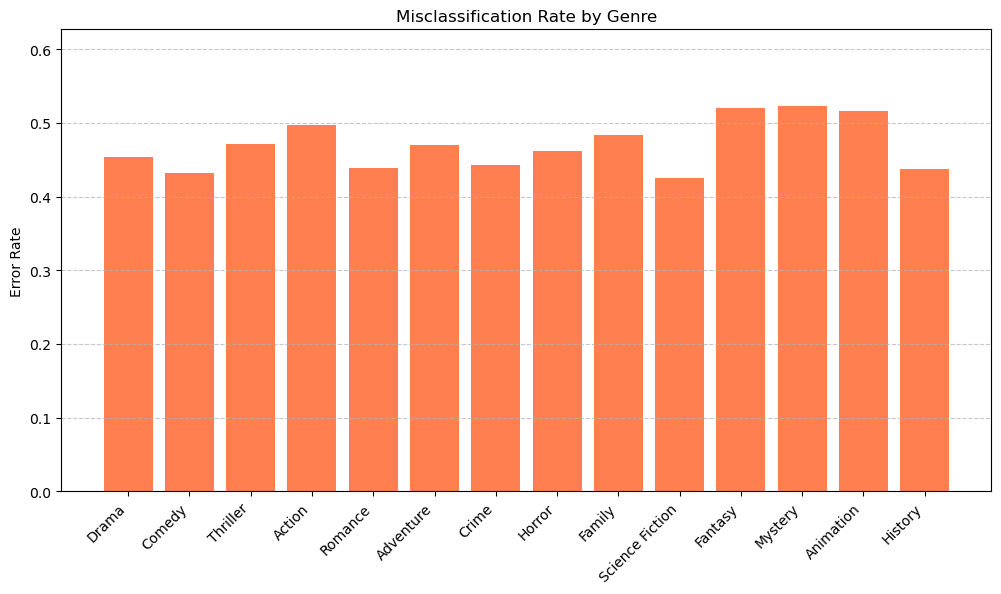

In [64]:
# Initialize lists for plotting
error_rates = []
genre_labels = []

# Loop through each genre
for genre in common_genres:
    # Identify movies that belong to this genre
    genre_mask = X_test[genre] == 1

    # Calculate error rate for this genre
    genre_error_rate = ((y_pred != y_test_r) & genre_mask).sum() / genre_mask.sum()

    error_rates.append(genre_error_rate)
    genre_labels.append(genre)

    print(f"❗ Error Rate – {genre}: {genre_error_rate:.2%}")

# Plotting the misclassification rates
plt.figure(figsize=(12, 6))
plt.bar(genre_labels, error_rates, color='coral')
plt.title('Misclassification Rate by Genre')
plt.ylabel('Error Rate')
plt.ylim(0, max(error_rates) * 1.2)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


#### 🧠 What We Checked  
We examined whether the model tends to misclassify movies from certain genres more often than others.

#### 🔍 Key Findings  
- Error rates are fairly close across genres overall.  
- Slightly higher misclassification rates were observed for *Fantasy*, *Mystery*, and *Animation* films.  
- Genres like *Comedy*, *Romance*, and *Science Fiction* show lower misclassification rates.

#### 📊 Conclusion  
The model appears to struggle more with genres that have less predictable or more complex rating patterns, such as *Mystery* or *Fantasy*. This may reflect genre-specific challenges in capturing rating behavior. Monitoring genre-based performance is important to ensure model robustness and avoid genre-related biases in recommendations.

___

### ✅ Question 2: Does the model systematically misclassify movies from certain decades?

🧠 **What does this check?**  
This analysis investigates whether the model performs equally well across different **release decades** — for example, the 1990s, 2000s, or 2010s.  
We calculate the misclassification rate within each decade to detect patterns.

If one decade shows a **significantly higher error rate**, it may indicate a **temporal bias** or that the model struggles with older or newer movie patterns.


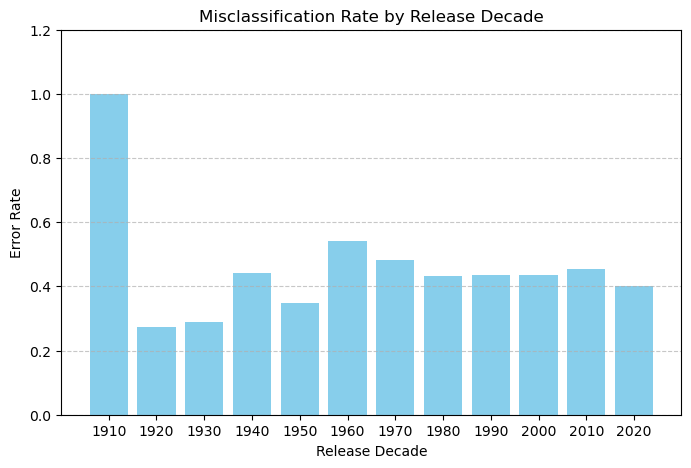

In [65]:
# Step 1: Get the release_decade values for each sample
decades = X_test_r['release_decade'].unique()
decades = sorted(decades)  # Sort decades for consistency

# Step 2: Calculate misclassification rate for each decade
error_rates = []
labels = []

for decade in decades:
    mask = X_test_r['release_decade'] == decade
    if mask.sum() == 0:
        continue 
    error_rate = ((y_pred != y_test_r) & mask).sum() / mask.sum()
    error_rates.append(error_rate)
    labels.append(str(int(decade)))


plt.figure(figsize=(8, 5))
plt.bar(labels, error_rates, color='skyblue')
plt.title('Misclassification Rate by Release Decade')
plt.xlabel('Release Decade')
plt.ylabel('Error Rate')
plt.ylim(0, max(error_rates)*1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### 🧠 What We Checked  
We analyzed whether the model's misclassification rates vary across different release decades.

#### 🔍 Key Findings  
- Movies from the 1910s show a 100% error rate (likely due to very small sample size).  
- Misclassification rates stabilize from the 1940s onward.  
- Higher error rates were observed for movies from the 1960s and 1970s.

#### 📊 Conclusion  
The model may have more difficulty with older films, possibly due to differences in data quality, available features, or shifts in cinematic trends.  
This suggests a need to explore potential adjustments for historical data to maintain consistent model performance across time periods.

___


### ✅ Question 3: Is the model overly sensitive to financial variables like `profit_or_loss`?

🧠 **What does this check?**  
We evaluate whether the model is more likely to misclassify movies based on their financial success.  
To do this, we split the data into two groups:
- Movies with **positive profit** (i.e., revenue > budget)
- Movies with **negative profit** (i.e., revenue ≤ budget)

We then compute the **misclassification rate** within each group.

📊 **Why does this matter?**  
If the model consistently performs worse on one group, it might be **over-relying on financial variables** to predict ratings.  
This could indicate **bias or overfitting** to profitability signals, rather than learning generalizable features.

> A fair model should maintain similar performance across both profitable and unprofitable movies unless there’s a strong justified pattern in the data.


💰 Error Rate – Positive Profit: 44.39%
🔻 Error Rate – Negative Profit: 43.66%


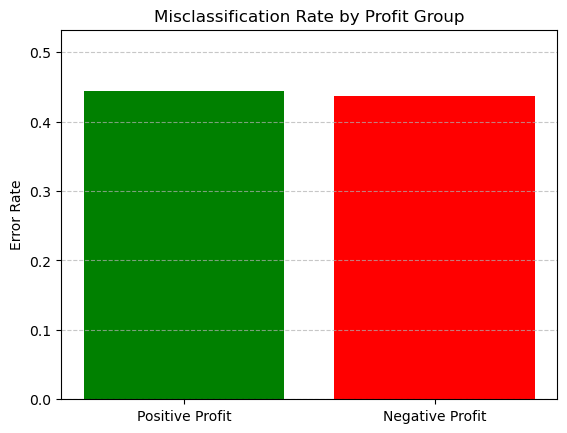

In [66]:
# Define groups: Positive profit vs. Negative profit
positive_profit_mask = X_test['profit_or_loss'] >= 0
negative_profit_mask = X_test['profit_or_loss'] < 0

# Calculate misclassification rate for each group
error_positive_profit = ((y_pred != y_test_r) & positive_profit_mask).sum() / positive_profit_mask.sum()
error_negative_profit = ((y_pred != y_test_r) & negative_profit_mask).sum() / negative_profit_mask.sum()

# Print results
print(f"💰 Error Rate – Positive Profit: {error_positive_profit:.2%}")
print(f"🔻 Error Rate – Negative Profit: {error_negative_profit:.2%}")

# Plot bar chart
error_rates = [error_positive_profit, error_negative_profit]
labels = ['Positive Profit', 'Negative Profit']

plt.bar(labels, error_rates, color=['green', 'red'])
plt.title('Misclassification Rate by Profit Group')
plt.ylabel('Error Rate')
plt.ylim(0, max(error_rates) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### 🧠 What We Checked  
We calculated the misclassification rates for movies with **positive profit** versus those with **negative profit** based on the `profit_or_loss` feature.

#### 🔍 Key Findings  
- **Positive Profit** misclassification rate: 44.39%  
- **Negative Profit** misclassification rate: 43.66%  
- No substantial difference between the two groups.

#### 📊 Conclusion  
The model does not appear to exhibit bias based on a movie's financial success. Prediction performance is stable across both profitable and unprofitable movies, suggesting that profit does not strongly influence misclassification rates.

_____

## 🧪 Full Classification Pipeline

In the main project, we focused on building and interpreting a **single Decision Tree** to keep the model interpretable.  
However, as a **bonus step**, we implemented a full pipeline that tests **multiple classifiers** side by side — to find out which model performs best on this problem.

This pipeline is built using a clean and modular `MovieRatingClassifier` class, which includes:

- **📦 Preprocessing**:  
  Scaling numerical features and one-hot encoding categorical ones using `ColumnTransformer`.

- **🔁 Train-Test Split**:  
  Splitting the dataset into training and test sets with stratification.

- **🤖 Model Training**:  
  Automatically trains multiple models including:  
  Logistic Regression, K-Nearest Neighbors, SVC, Random Forest, Gradient Boosting, XGBoost, LightGBM, and CatBoost.

- **📈 Evaluation**:  
  For each model, it computes:
  - Accuracy
  - F1-score
  - Confusion Matrix
  - ROC Curves (if supported)

- **🏆 Model Comparison**:  
  The results are displayed in a **summary table and performance plots**, helping us easily identify the most accurate and reliable classifier.

> 💡 This allows us to go beyond interpretability and get a broader view of which models are most effective — which is useful if we want to trade interpretability for performance in future work.

> ❗ **Note**: In general - We can pick what features to use in the preprocess by inputing exactly what features to check.  
We used the same features that we eventualy used in our Decision Tree to have an even comparison (default option).


In [67]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, roc_curve, auc, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from optuna.samplers import TPESampler
import warnings
warnings.filterwarnings('ignore')

# Disable Optuna logging for cleaner output
optuna.logging.set_verbosity(optuna.logging.WARNING)

class MovieRatingClassifier:
    def __init__(self, df):
        self.df = df.copy()
        self.X = None
        self.y = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.numeric_features = []
        self.categorical_features = []
        self.models = {}
        self.results = {}
        self.tuned_results = {}
        self.best_studies = {}
        self.class_names = []
        self.label_dict = {
            0: 'Low (<6.2)',
            1: 'Medium (6.2–6.8)',
            2: 'High (>6.8)'
        }

    def preprocess_data(self, features_to_keep, target_col='weighted_rating', test_size=0.2, random_state=42):
        print("\U0001f504 Starting data preprocessing...")

        self.df['rating_category'] = pd.cut(
            self.df[target_col],
            bins=[-np.inf, 6.2, 6.8, np.inf],
            labels=[0, 1, 2]
        ).astype(int)

        self.y = self.df['rating_category']
        self.class_names = sorted(self.y.unique().astype(str))

        self.X = self.df[features_to_keep]
        print(f"Features kept: {features_to_keep}")

        self.numeric_features = self.X.select_dtypes(include=np.number).columns.tolist()
        self.categorical_features = self.X.select_dtypes(include=['object', 'bool']).columns.tolist()

        print(f"\U0001f4ca {len(self.categorical_features)} categorical, {len(self.numeric_features)} numerical features.")

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=test_size, random_state=random_state, stratify=self.y
        )

        print("✅ Preprocessing complete")
        print(f"Train: {self.X_train.shape}, Test: {self.X_test.shape}")

        return self
    
    def train_baseline_models(self, include_best_bayes=True, best_bayes_model=None):
        print("\n\U0001f916 Training baseline classification models...")

        models = {
            'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
            'KNN': KNeighborsClassifier(),
            'SVC': SVC(probability=True, random_state=42),
            'Random Forest': RandomForestClassifier(random_state=42),
            'Gradient Boosting': GradientBoostingClassifier(random_state=42),
            'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
            'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
            'CatBoost': CatBoostClassifier(verbose=0, random_state=42)
        }

        # Add best bayes model if provided
        if include_best_bayes and best_bayes_model is not None:
            models['Best Bayes Model'] = best_bayes_model

        for name, model in models.items():
            print(f"Training {name}...")

            # Build preprocessor fresh inside the pipeline
            preprocessor = ColumnTransformer([
                ('num', StandardScaler(), self.numeric_features),
                ('cat', OneHotEncoder(handle_unknown='ignore'), self.categorical_features)
            ])

            pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
            pipe.fit(self.X_train, self.y_train)

            y_pred = pipe.predict(self.X_test)
            y_proba = pipe.predict_proba(self.X_test) if hasattr(model, 'predict_proba') else None

            acc = accuracy_score(self.y_test, y_pred)
            f1 = f1_score(self.y_test, y_pred, average='weighted')

            self.results[name] = {
                'model': pipe,
                'accuracy': acc,
                'f1_score': f1,
                'predictions': y_pred,
                'predict_proba': y_proba
            }

            print(f"  ✅ Accuracy: {acc:.4f}, F1: {f1:.4f}")

        return self

    def _create_objective(self, model_name, n_trials=100):
        """Create objective function for Optuna optimization"""
        
        def objective(trial):
            # Define hyperparameter search spaces for each model
            if model_name == 'Logistic Regression':
                params = {
                    'C': trial.suggest_float('C', 0.01, 100, log=True),
                    'solver': trial.suggest_categorical('solver', ['liblinear', 'lbfgs']),
                    'max_iter': trial.suggest_int('max_iter', 1000, 5000),
                    'random_state': 42
                }
                model = LogisticRegression(**params)
                
            elif model_name == 'Random Forest':
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 50, 500),
                    'max_depth': trial.suggest_int('max_depth', 3, 20),
                    'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
                    'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
                    'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
                    'random_state': 42
                }
                model = RandomForestClassifier(**params)
                
            elif model_name == 'XGBoost':
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 50, 500),
                    'max_depth': trial.suggest_int('max_depth', 3, 10),
                    'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
                    'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                    'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
                    'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
                    'use_label_encoder': False,
                    'eval_metric': 'mlogloss',
                    'random_state': 42
                }
                model = XGBClassifier(**params)
                
            elif model_name == 'LightGBM':
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 50, 500),
                    'num_leaves': trial.suggest_int('num_leaves', 10, 300),
                    'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
                    'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
                    'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
                    'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
                    'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
                    'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
                    'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
                    'random_state': 42,
                    'verbose': -1
                }
                model = LGBMClassifier(**params)
                
            elif model_name == 'CatBoost':
                params = {
                    'iterations': trial.suggest_int('iterations', 50, 500),
                    'depth': trial.suggest_int('depth', 3, 10),
                    'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
                    'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
                    'random_state': 42,
                    'verbose': 0
                }
                model = CatBoostClassifier(**params)
                
            elif model_name == 'SVC':
                params = {
                    'C': trial.suggest_float('C', 0.1, 100, log=True),
                    'kernel': trial.suggest_categorical('kernel', ['rbf', 'poly', 'sigmoid']),
                    'gamma': trial.suggest_categorical('gamma', ['scale', 'auto']),
                    'probability': True,
                    'random_state': 42
                }
                if params['kernel'] == 'poly':
                    params['degree'] = trial.suggest_int('degree', 2, 5)
                model = SVC(**params)
                
            elif model_name == 'KNN':
                params = {
                    'n_neighbors': trial.suggest_int('n_neighbors', 3, 50),
                    'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
                    'algorithm': trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree', 'brute']),
                    'p': trial.suggest_int('p', 1, 2)
                }
                model = KNeighborsClassifier(**params)
                
            elif model_name == 'Gradient Boosting':
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 50, 500),
                    'max_depth': trial.suggest_int('max_depth', 3, 10),
                    'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
                    'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                    'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
                    'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
                    'random_state': 42
                }
                model = GradientBoostingClassifier(**params)
            
            else:
                raise ValueError(f"Model {model_name} not supported for hyperparameter tuning")

            # Create pipeline with preprocessor
            preprocessor = ColumnTransformer([
                ('num', StandardScaler(), self.numeric_features),
                ('cat', OneHotEncoder(handle_unknown='ignore'), self.categorical_features)
            ])
            
            pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
            
            # Use cross-validation for more robust evaluation
            cv_scores = cross_val_score(pipe, self.X_train, self.y_train, 
                                      cv=5, scoring='f1_weighted', n_jobs=-1)
            
            return cv_scores.mean()

        return objective

    def tune_hyperparameters(self, models_to_tune=None, n_trials=100, timeout=None):
        """
        Tune hyperparameters using Optuna
        
        Args:
            models_to_tune: List of model names to tune. If None, tunes all models except Best Bayes Model
            n_trials: Number of trials per model
            timeout: Time limit in seconds for each model's optimization
        """
        print(f"\n\U0001f50d Starting hyperparameter tuning with Optuna ({n_trials} trials per model)...")
        
        if models_to_tune is None:
            # Tune all models except the baseline comparison model
            models_to_tune = [name for name in self.results.keys() 
                            if name != 'Best Bayes Model' and name != 'Decision Tree']
            
        # Ensure we only tune models that support hyperparameter optimization
        supported_models = ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 
                          'CatBoost', 'SVC', 'KNN', 'Gradient Boosting']
        models_to_tune = [m for m in models_to_tune if m in supported_models]
        
        print(f"Tuning models: {models_to_tune}")
        
        for model_name in models_to_tune:
            print(f"\n🔧 Tuning {model_name}...")
            
            # Create study
            study = optuna.create_study(
                direction='maximize',
                sampler=TPESampler(seed=42),
                study_name=f"{model_name}_optimization"
            )
            
            # Create objective function
            objective = self._create_objective(model_name, n_trials)
            
            # Optimize (disable progress bar and logging for cleaner output)
            study.optimize(objective, n_trials=n_trials, timeout=timeout, show_progress_bar=False)
            
            # Store best study
            self.best_studies[model_name] = study
            
            print(f"  ✅ Best CV F1 Score: {study.best_value:.4f}")
            print(f"  📋 Best params: {study.best_params}")
            
        return self

    def train_tuned_models(self):
        """Train models with best hyperparameters found by Optuna"""
        print("\n\U0001f680 Training models with optimized hyperparameters...")
        
        for model_name, study in self.best_studies.items():
            print(f"Training optimized {model_name}...")
            
            # Get best parameters
            best_params = study.best_params
            
            # Create model with best parameters
            if model_name == 'Logistic Regression':
                model = LogisticRegression(**best_params)
            elif model_name == 'Random Forest':
                model = RandomForestClassifier(**best_params)
            elif model_name == 'XGBoost':
                model = XGBClassifier(**best_params)
            elif model_name == 'LightGBM':
                model = LGBMClassifier(**best_params)
            elif model_name == 'CatBoost':
                model = CatBoostClassifier(**best_params)
            elif model_name == 'SVC':
                model = SVC(**best_params)
            elif model_name == 'KNN':
                model = KNeighborsClassifier(**best_params)
            elif model_name == 'Gradient Boosting':
                model = GradientBoostingClassifier(**best_params)
            
            # Create pipeline
            preprocessor = ColumnTransformer([
                ('num', StandardScaler(), self.numeric_features),
                ('cat', OneHotEncoder(handle_unknown='ignore'), self.categorical_features)
            ])
            
            pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
            
            # Train and evaluate
            pipe.fit(self.X_train, self.y_train)
            y_pred = pipe.predict(self.X_test)
            y_proba = pipe.predict_proba(self.X_test) if hasattr(model, 'predict_proba') else None
            
            acc = accuracy_score(self.y_test, y_pred)
            f1 = f1_score(self.y_test, y_pred, average='weighted')
            
            # Store tuned results
            self.tuned_results[f"{model_name} (Tuned)"] = {
                'model': pipe,
                'accuracy': acc,
                'f1_score': f1,
                'predictions': y_pred,
                'predict_proba': y_proba,
                'best_params': best_params,
                'cv_score': study.best_value
            }
            
            print(f"  ✅ Test Accuracy: {acc:.4f}, F1: {f1:.4f} (CV: {study.best_value:.4f})")
            
        return self

    def compare_baseline_vs_tuned(self):
        """Compare baseline and tuned model performance"""
        print("\n\U0001f4ca Baseline vs Tuned Model Comparison")
        
        comparison_data = []
        
        for model_name in self.best_studies.keys():
            if model_name in self.results:
                baseline_f1 = self.results[model_name]['f1_score']
                baseline_acc = self.results[model_name]['accuracy']
                
                tuned_name = f"{model_name} (Tuned)"
                if tuned_name in self.tuned_results:
                    tuned_f1 = self.tuned_results[tuned_name]['f1_score']
                    tuned_acc = self.tuned_results[tuned_name]['accuracy']
                    
                    comparison_data.append({
                        'Model': model_name,
                        'Baseline_F1': baseline_f1,
                        'Tuned_F1': tuned_f1,
                        'F1_Improvement': tuned_f1 - baseline_f1,
                        'Baseline_Accuracy': baseline_acc,
                        'Tuned_Accuracy': tuned_acc,
                        'Accuracy_Improvement': tuned_acc - baseline_acc
                    })
        
        df_comparison = pd.DataFrame(comparison_data)
        df_comparison = df_comparison.round(4)
        print(df_comparison.to_string(index=False))
        
        # Summary
        avg_f1_improvement = df_comparison['F1_Improvement'].mean()
        avg_acc_improvement = df_comparison['Accuracy_Improvement'].mean()
        
        print(f"\n📈 Average F1 improvement: {avg_f1_improvement:.4f}")
        print(f"📈 Average Accuracy improvement: {avg_acc_improvement:.4f}")
        
        return df_comparison

    def evaluate_models(self, include_tuned=True):
        """Evaluate all models (baseline and tuned)"""
        print("\n\U0001f4ca Model Evaluation Summary")
        
        all_results = self.results.copy()
        if include_tuned:
            all_results.update(self.tuned_results)
        
        df_results = pd.DataFrame({
            'Model': list(all_results.keys()),
            'Accuracy': [all_results[m]['accuracy'] for m in all_results],
            'F1_Score': [all_results[m]['f1_score'] for m in all_results]
        }).sort_values(by='F1_Score', ascending=False).reset_index(drop=True)

        print(df_results.to_string(index=False))

        best_model_name = df_results.iloc[0]['Model']
        y_true_named = [self.label_dict[y] for y in self.y_test]
        y_pred_named = [self.label_dict[y] for y in all_results[best_model_name]['predictions']]

        print(f"\n\U0001f3c6 Best Model: {best_model_name}")
        print(classification_report(y_true_named, y_pred_named, target_names=self.label_dict.values()))

        return df_results, best_model_name

    def plot_tuning_results(self):
        """Plot optimization history for tuned models"""
        if not self.best_studies:
            print("No tuning results to plot.")
            return
        
        n_models = len(self.best_studies)
        n_cols = min(3, n_models)
        n_rows = (n_models + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
        if n_models == 1:
            axes = [axes]
        elif n_rows == 1:
            axes = axes.reshape(1, -1)
        
        for idx, (model_name, study) in enumerate(self.best_studies.items()):
            row = idx // n_cols
            col = idx % n_cols
            ax = axes[row, col] if n_rows > 1 else axes[col]
            
            # Plot optimization history
            trials = study.trials
            values = [trial.value for trial in trials if trial.value is not None]
            
            ax.plot(values, alpha=0.7)
            ax.axhline(y=study.best_value, color='red', linestyle='--', 
                      label=f'Best: {study.best_value:.4f}')
            ax.set_title(f'{model_name} Optimization')
            ax.set_xlabel('Trial')
            ax.set_ylabel('F1 Score')
            ax.legend()
            ax.grid(True, alpha=0.3)
        
        # Hide empty subplots
        for idx in range(n_models, n_rows * n_cols):
            row = idx // n_cols
            col = idx % n_cols
            if n_rows > 1:
                axes[row, col].set_visible(False)
            else:
                axes[col].set_visible(False)
        
        plt.tight_layout()
        plt.show()

    def check_overfitting(self, threshold=0.1):
        """Check overfitting for all models"""
        print("\n\U0001f9ea Overfitting Check Summary")
        
        all_results = {**self.results, **self.tuned_results}
        
        for name, result in all_results.items():
            model_pipe = result['model']
            
            train_preds = model_pipe.predict(self.X_train)
            test_preds = model_pipe.predict(self.X_test)

            train_acc = accuracy_score(self.y_train, train_preds)
            test_acc = accuracy_score(self.y_test, test_preds)

            print(f"\nModel: {name}")
            print(f"  Train Accuracy: {train_acc:.4f}")
            print(f"  Test Accuracy:  {test_acc:.4f}")
            
            if train_acc - test_acc > threshold:
                print("  ⚠️  Warning: Model might be overfitting.")
            else:
                print("  ✅ Model seems to generalize well.")
                
    def plot_results(self, include_tuned=True):
        """Plot comprehensive results including tuned models"""
        all_results = self.results.copy()
        if include_tuned:
            all_results.update(self.tuned_results)
            
        if not all_results:
            print("No trained models.")
            return

        best = max(all_results, key=lambda m: all_results[m]['f1_score'])
        y_pred = all_results[best]['predictions']
        y_proba = all_results[best]['predict_proba']

        fig, axes = plt.subplots(2, 2, figsize=(16, 14))
        fig.suptitle('Model Performance Summary', fontsize=20)

        models = list(all_results.keys())
        f1s = [all_results[m]['f1_score'] for m in models]
        accs = [all_results[m]['accuracy'] for m in models]

        sns.barplot(x=f1s, y=models, palette='viridis', ax=axes[0, 0])
        axes[0, 0].set_title("F1-Score")
        axes[0, 0].set_xlabel("F1")
        axes[0, 0].set_ylabel("Model")
        
        sns.barplot(x=accs, y=models, palette='flare', ax=axes[0, 1])
        axes[0, 1].set_title("Accuracy")
        axes[0, 1].set_xlabel("Accuracy")
        axes[0, 1].set_ylabel("")

        cm = confusion_matrix(self.y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
                    xticklabels=self.label_dict.values(),
                    yticklabels=self.label_dict.values())
        axes[1, 0].set_title(f'Confusion Matrix - {best}')
        axes[1, 0].set_xlabel('Predicted')
        axes[1, 0].set_ylabel('Actual')

        if y_proba is not None:
            y_test_bin = OneHotEncoder(sparse_output=False).fit_transform(self.y_test.values.reshape(-1, 1))
            fpr, tpr, roc_auc = {}, {}, {}
            for i in range(len(self.class_names)):
                fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
                roc_auc[i] = auc(fpr[i], tpr[i])
            for i in range(len(self.class_names)):
                axes[1, 1].plot(fpr[i], tpr[i], label=f"{self.label_dict[i]} (AUC = {roc_auc[i]:.2f})")
            axes[1, 1].plot([0, 1], [0, 1], 'k--')
            axes[1, 1].legend()
            axes[1, 1].set_title(f'ROC Curve - {best}')
            axes[1, 1].set_xlabel('FPR')
            axes[1, 1].set_ylabel('TPR')
        else:
            axes[1, 1].text(0.5, 0.5, 'No predict_proba()', ha='center', fontsize=12)

        plt.tight_layout()
        plt.show()

    def get_feature_importance(self, model_name=None):
        """Get feature importance from the best model or specified model"""
        all_results = {**self.results, **self.tuned_results}
        
        if model_name is None:
            model_name = max(all_results, key=lambda m: all_results[m]['f1_score'])
        
        if model_name not in all_results:
            print(f"Model {model_name} not found.")
            return None
        
        model_pipe = all_results[model_name]['model']
        classifier = model_pipe.named_steps['classifier']
        
        # Get feature names after preprocessing
        preprocessor = model_pipe.named_steps['preprocessor']
        feature_names = (self.numeric_features + 
                        list(preprocessor.named_transformers_['cat'].get_feature_names_out(self.categorical_features)))
        
        # Extract feature importance
        if hasattr(classifier, 'feature_importances_'):
            importance = classifier.feature_importances_
            importance_df = pd.DataFrame({
                'Feature': feature_names,
                'Importance': importance
            }).sort_values('Importance', ascending=False)
            
            print(f"\n🔍 Feature Importance - {model_name}")
            print(importance_df.head(10).to_string(index=False))
            
            return importance_df
        else:
            print(f"Model {model_name} doesn't have feature_importances_ attribute.")
            return None

🔄 Starting data preprocessing...
Features kept: ['runtime', 'popularity_percentile', 'profit_or_loss', 'popularity', 'revenue', 'release_decade', 'Drama', 'Thriller', 'Horror', 'Animation', 'changed_title']
📊 5 categorical, 6 numerical features.
✅ Preprocessing complete
Train: (7962, 11), Test: (1991, 11)

🤖 Training baseline classification models...
Training Logistic Regression...
  ✅ Accuracy: 0.5947, F1: 0.5950
Training KNN...
  ✅ Accuracy: 0.5470, F1: 0.5458
Training SVC...
  ✅ Accuracy: 0.6087, F1: 0.6086
Training Random Forest...
  ✅ Accuracy: 0.5907, F1: 0.5909
Training Gradient Boosting...
  ✅ Accuracy: 0.6183, F1: 0.6186
Training XGBoost...
  ✅ Accuracy: 0.6047, F1: 0.6048
Training LightGBM...
  ✅ Accuracy: 0.6158, F1: 0.6160
Training CatBoost...
  ✅ Accuracy: 0.6148, F1: 0.6152

🔍 Starting hyperparameter tuning with Optuna (50 trials per model)...
Tuning models: ['Logistic Regression', 'KNN', 'SVC', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM', 'CatBoost']

🔧 T

/opt/homebrew/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:42:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:42:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:42:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:42:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not use

  ✅ Best CV F1 Score: 0.6072
  📋 Best params: {'n_estimators': 224, 'max_depth': 4, 'learning_rate': 0.09251510804193808, 'subsample': 0.6005800047171014, 'colsample_bytree': 0.831071772317934, 'reg_alpha': 0.04705576078995166, 'reg_lambda': 6.811760424708317}

🔧 Tuning LightGBM...


/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  

  ✅ Best CV F1 Score: 0.6083
  📋 Best params: {'n_estimators': 360, 'num_leaves': 13, 'learning_rate': 0.11510253157521858, 'feature_fraction': 0.7136660709118446, 'bagging_fraction': 0.6985372368668294, 'bagging_freq': 3, 'min_child_samples': 31, 'reg_alpha': 9.41479357724739, 'reg_lambda': 0.5492575491604481}

🔧 Tuning CatBoost...
  ✅ Best CV F1 Score: 0.6121
  📋 Best params: {'iterations': 420, 'depth': 5, 'learning_rate': 0.08407860304190769, 'l2_leaf_reg': 3.5209571049515804}

🚀 Training models with optimized hyperparameters...
Training optimized Logistic Regression...
  ✅ Test Accuracy: 0.5942, F1: 0.5944 (CV: 0.5767)
Training optimized KNN...
  ✅ Test Accuracy: 0.5736, F1: 0.5738 (CV: 0.5755)
Training optimized SVC...
  ✅ Test Accuracy: 0.6153, F1: 0.6156 (CV: 0.5939)
Training optimized Random Forest...
  ✅ Test Accuracy: 0.6163, F1: 0.6167 (CV: 0.6001)
Training optimized Gradient Boosting...
  ✅ Test Accuracy: 0.6283, F1: 0.6287 (CV: 0.6070)
Training optimized XGBoost...
  ✅ Te

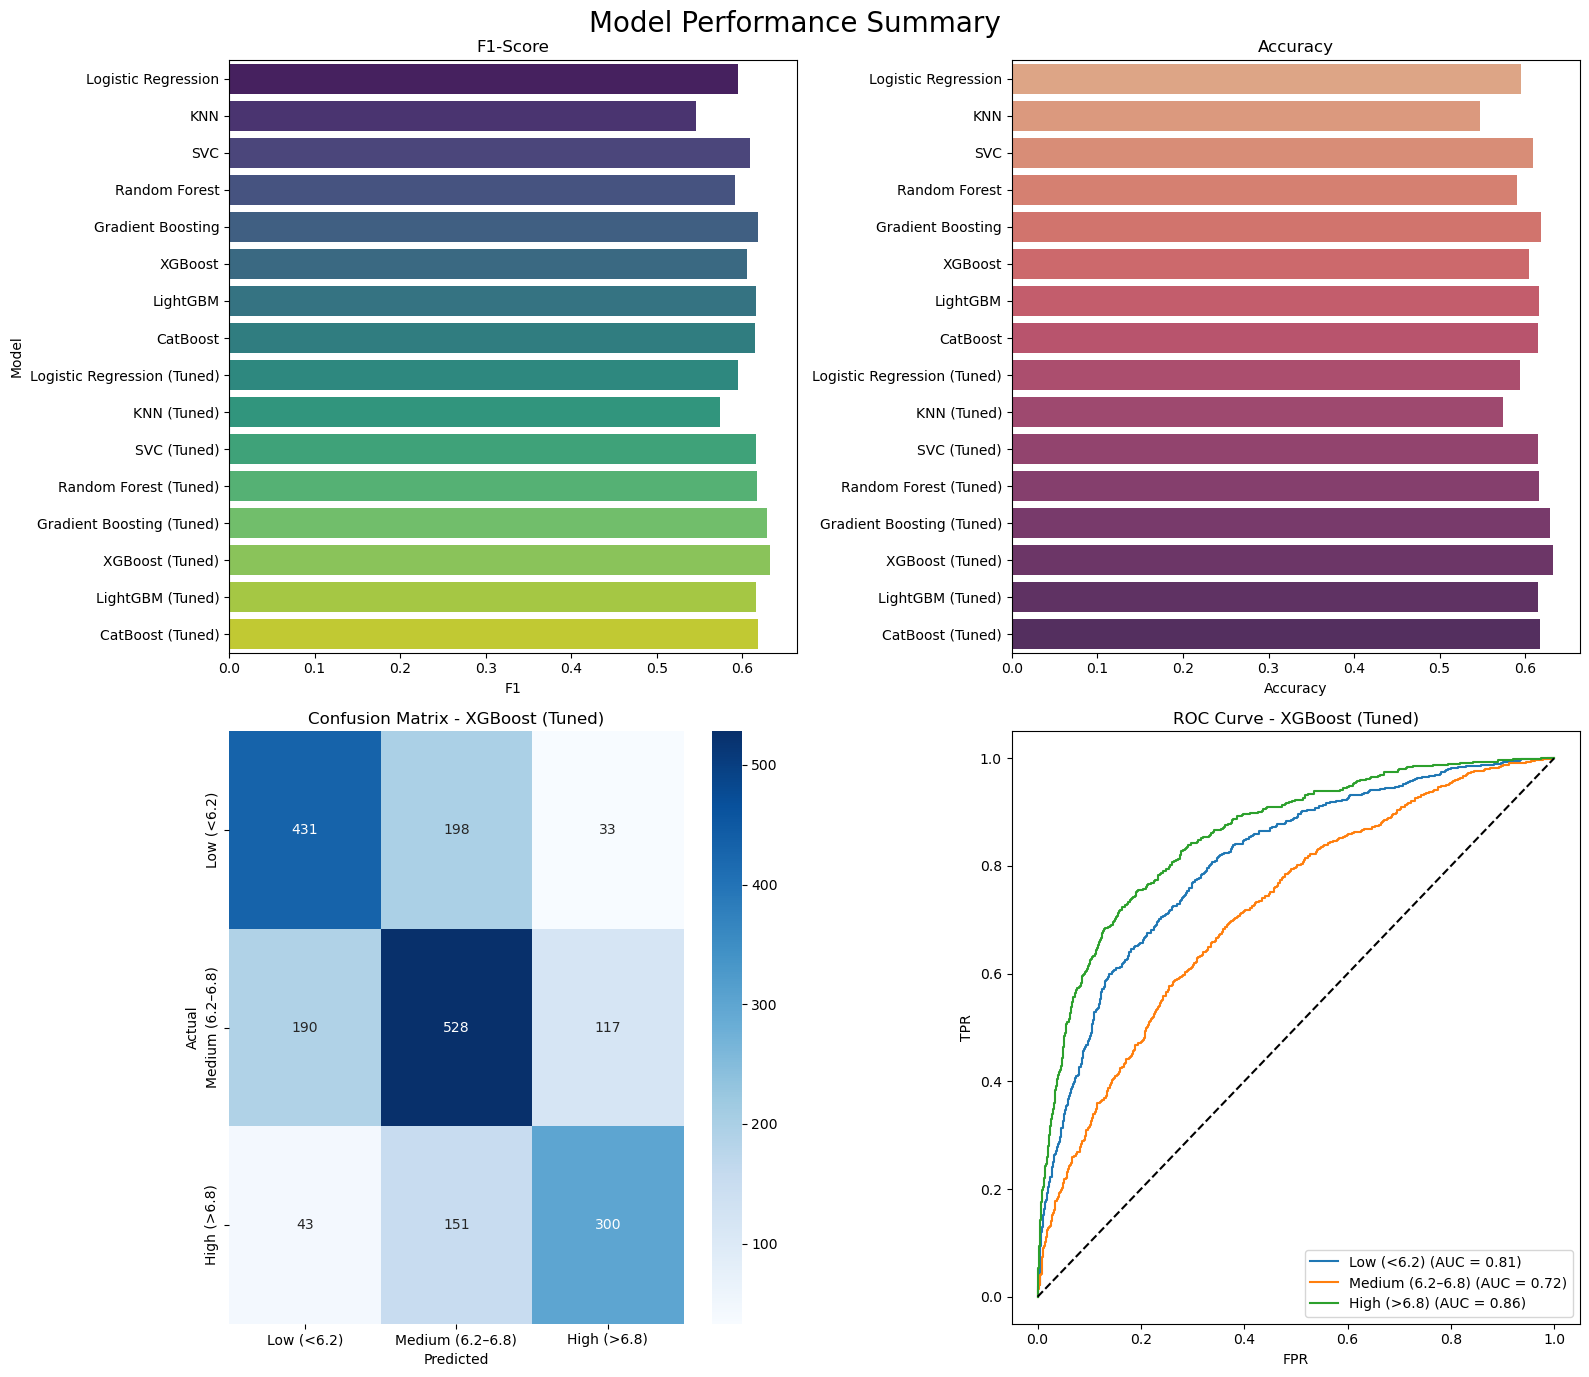

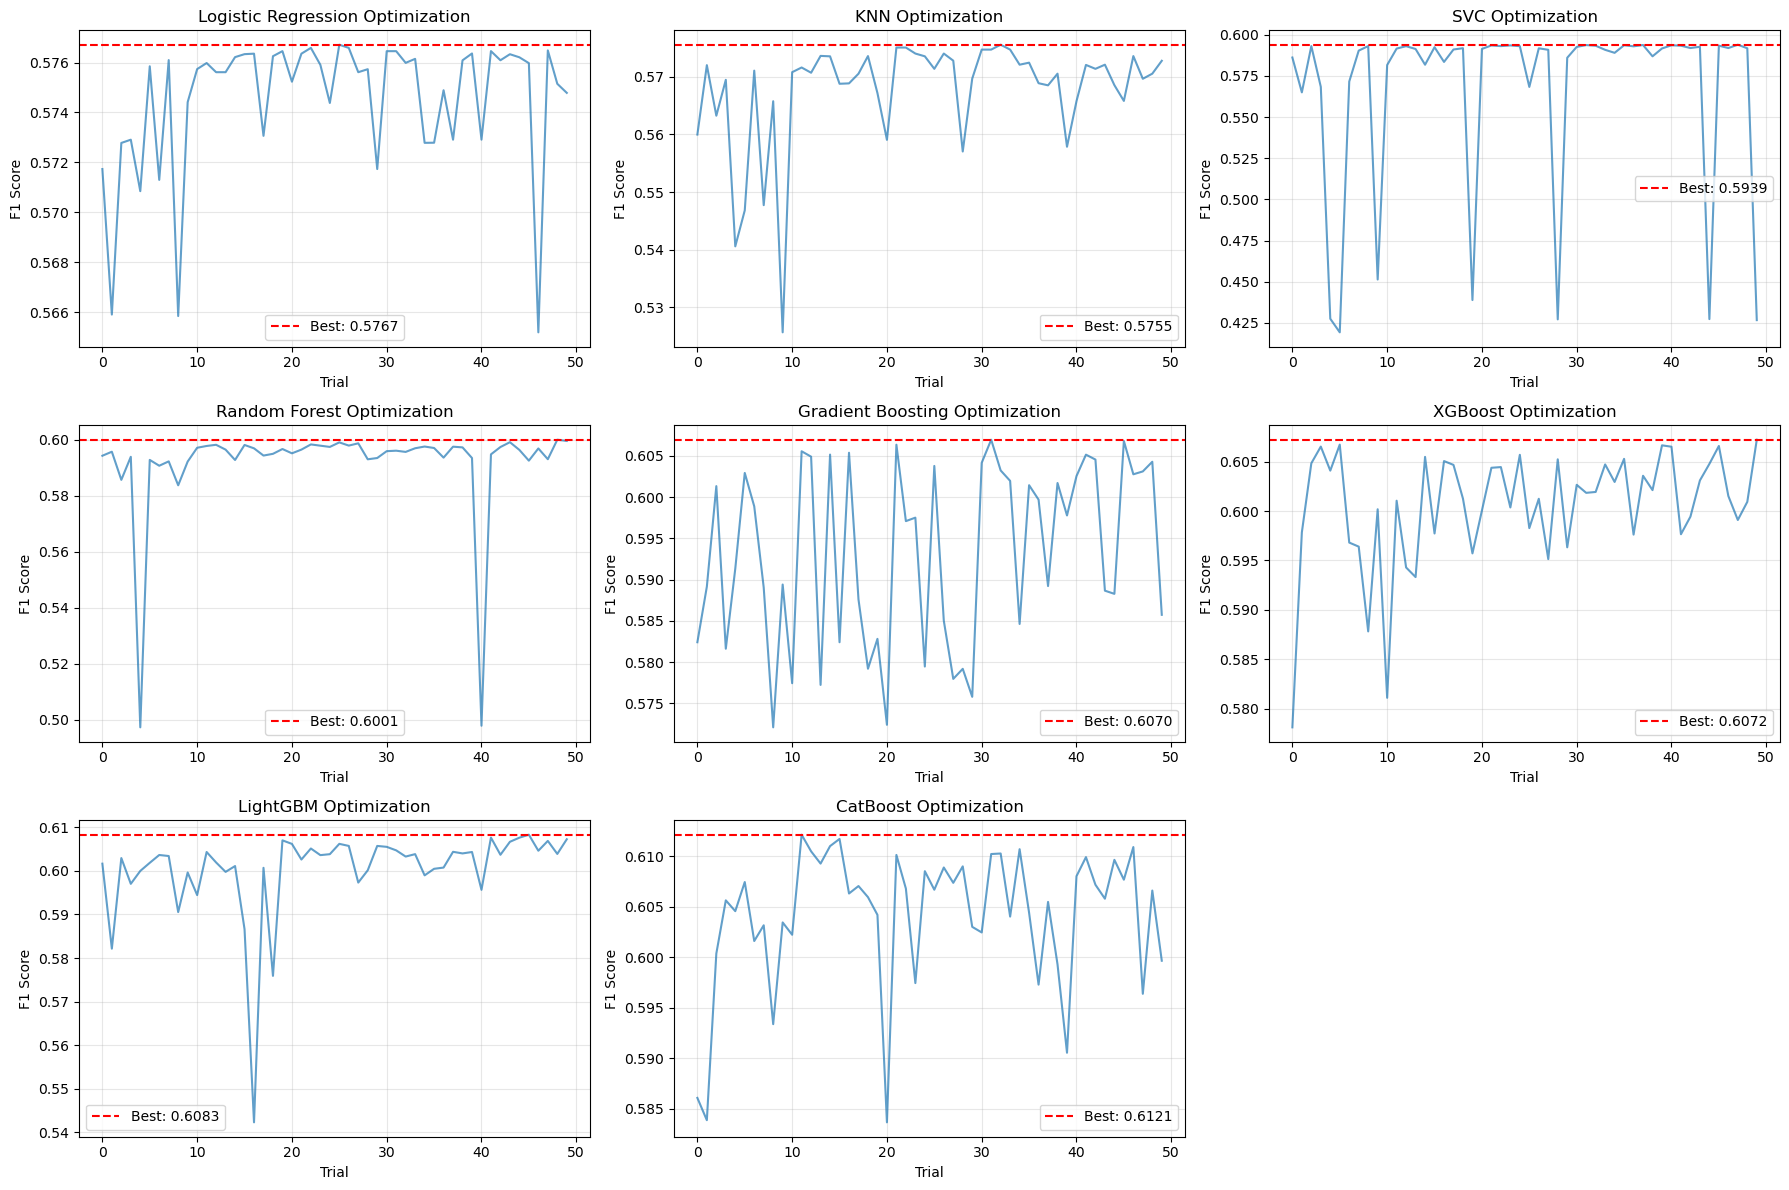


🧪 Overfitting Check Summary

Model: Logistic Regression
  Train Accuracy: 0.5799
  Test Accuracy:  0.5947
  ✅ Model seems to generalize well.

Model: KNN
  Train Accuracy: 0.6831
  Test Accuracy:  0.5470
  ⚠️  Warning: Model might be overfitting.

Model: SVC
  Train Accuracy: 0.6024
  Test Accuracy:  0.6087
  ✅ Model seems to generalize well.

Model: Random Forest
  Train Accuracy: 1.0000
  Test Accuracy:  0.5907
  ⚠️  Warning: Model might be overfitting.

Model: Gradient Boosting
  Train Accuracy: 0.6486
  Test Accuracy:  0.6183
  ✅ Model seems to generalize well.

Model: XGBoost
  Train Accuracy: 0.8735
  Test Accuracy:  0.6047
  ⚠️  Warning: Model might be overfitting.

Model: LightGBM
  Train Accuracy: 0.7715
  Test Accuracy:  0.6158
  ⚠️  Warning: Model might be overfitting.

Model: CatBoost
  Train Accuracy: 0.7926
  Test Accuracy:  0.6148
  ⚠️  Warning: Model might be overfitting.

Model: Logistic Regression (Tuned)
  Train Accuracy: 0.5801
  Test Accuracy:  0.5942
  ✅ Model se

In [68]:

classifier = MovieRatingClassifier(data_copy)

classifier.preprocess_data(features_to_keep=reduced_features)

classifier.train_baseline_models(include_best_bayes=True)

classifier.tune_hyperparameters(n_trials=50)  

classifier.train_tuned_models()

comparison_df = classifier.compare_baseline_vs_tuned()

results_df, best_model = classifier.evaluate_models(include_tuned=True)

classifier.plot_results(include_tuned=True)
classifier.plot_tuning_results()

classifier.check_overfitting()

importance_df = classifier.get_feature_importance()


## 🎯 Model Evaluation Summary

We tested multiple classification models to predict movie rating categories based on selected features.
The **XGBoost (Tuned)** model achieved the highest performance, with:

* **Accuracy:** 63.2%
* **Weighted F1-score:** 63.3%

### 🏆 Best Model: XGBoost (Tuned)

| Rating Class         | Precision | Recall | F1-score | Support  |
| -------------------- | --------- | ------ | -------- | -------- |
| **Low (<6.2)**       | 0.67      | 0.61   | 0.64     | 494      |
| **Medium (6.2–6.8)** | 0.65      | 0.65   | 0.65     | 662      |
| **High (>6.8)**      | 0.60      | 0.63   | 0.62     | 835      |
| **Overall Accuracy** |           |        | **0.63** | **1991** |
| **Macro Average**    | 0.64      | 0.63   | 0.63     |          |
| **Weighted Avg**     | 0.63      | 0.63   | 0.63     |          |

---

## 📉 Confusion Matrix and ROC AUC Insights

The confusion matrix for XGBoost shows:

* Most misclassifications occur between **Low** and **Medium** ratings.
* **High** ratings are often confused with **Medium**, but rarely with **Low** — which shows good separation between the extremes.

ROC AUC scores per class:

* **Low:** 0.81
* **Medium:** 0.71
* **High:** 0.85

This suggests the model distinguishes **High** and **Low** ratings more confidently than **Medium**, which likely stems from overlapping distributions near the category thresholds.

---

## ⚙️ How XGBoost Works (Short Overview)

**XGBoost** (Extreme Gradient Boosting) is an optimized implementation of gradient boosting that includes regularization and system-level enhancements.

1️⃣ Builds trees **sequentially**, with each one correcting the previous trees’ errors.
2️⃣ Uses **second-order gradients** (Hessians) for more precise optimization.
3️⃣ Applies **shrinkage (learning rate)** and **subsampling** to reduce overfitting.
4️⃣ Supports **regularization (L1/L2)** to penalize complexity.
5️⃣ Highly efficient due to parallelized computation and cache-aware access patterns.

---

## 🔍 Why XGBoost Outperformed Other Models

After tuning and evaluating multiple models, **XGBoost (Tuned)** delivered the best overall accuracy and F1-score. Here's why:

### ✅ 1️⃣ Precise Gradient Updates

* XGBoost leverages **second-order gradient information** (not just residuals like standard GBMs), which allows for better handling of classification boundaries and more stable convergence.

### ✅ 2️⃣ Regularization Prevents Overfitting

* Built-in **L1 and L2 regularization** allows the model to generalize better than classical GBMs and Random Forests, especially in noisy or high-cardinality feature spaces.

### ✅ 3️⃣ Parallel and Optimized Training

* XGBoost implements **parallel tree construction** and efficient memory usage, enabling fast and scalable training even on relatively large datasets.

### ✅ 4️⃣ Fine-grained Control Over Model Complexity

* Parameters like `max_depth`, `subsample`, and `colsample_bytree` allow for tight control of bias-variance tradeoffs, crucial in this dataset where class boundaries are not linearly separable.

### ✅ 5️⃣ Strong Performance on Tabular Data

* Like Gradient Boosting, XGBoost shines in tabular data problems where feature interactions are subtle and high-dimensional.